In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Set your CAMUS dataset path here
DATASET_DIR = '/content/drive/MyDrive/Colab Notebooks/Camus_dataset'


Mounted at /content/drive


In [2]:
!pip install SimpleITK segmentation-models-pytorch albumentations


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 128.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 99.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 53.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 106.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-

In [3]:
import os
import SimpleITK as sitk
import numpy as np
import cv2

def load_mhd_slice(image_path):
    img = sitk.ReadImage(image_path)
    img_np = sitk.GetArrayFromImage(img)[0]  # Use first slice
    return img_np

def preprocess_image_mask(image_path, mask_path, size=(256, 256)):
    image = load_mhd_slice(image_path)
    mask = load_mhd_slice(mask_path)

    image = cv2.resize(image, size)
    mask = cv2.resize(mask, size, interpolation=cv2.INTER_NEAREST)

    image = np.expand_dims(image, axis=0)  # Add channel dimension
    mask = np.eye(4)[mask].transpose(2, 0, 1)[1:]  # One-hot encode for 3 classes: LVEndo, LVEpi, LA
    return image / 255.0, mask.astype(np.float32)


In [4]:
from torch.utils.data import Dataset, DataLoader
import torch

class CAMUSDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_paths = sorted([os.path.join(img_dir, f) for f in os.listdir(img_dir) if f.endswith('.mhd')])
        self.mask_paths = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir) if f.endswith('.mhd')])
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        image, mask = preprocess_image_mask(self.img_paths[idx], self.mask_paths[idx])
        return torch.tensor(image, dtype=torch.float32), torch.tensor(mask, dtype=torch.float32)


In [5]:
!pip install segmentation-models-pytorch --quiet


In [6]:
!pip install torch torchvision --quiet
!pip install efficientnet_pytorch --quiet


  Preparing metadata (setup.py) ... done


In [7]:
!pip install torch torchvision --quiet
!pip install segmentation-models-pytorch --quiet
!pip install efficientnet_pytorch --quiet


In [8]:
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=1,
    classes=3
)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [9]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [10]:
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=1,     # grayscale ultrasound images
    classes=3          # LVEndo, LVEpi, LA masks
)
model = model.to(device)


In [11]:
!pip install SimpleITK --quiet


In [12]:
import torch
from torch.utils.data import Dataset
import SimpleITK as sitk
import numpy as np
import os
import cv2

class CamusDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load image
        img = sitk.ReadImage(self.image_paths[idx])
        img_array = sitk.GetArrayFromImage(img)[0]  # shape: (H, W)

        # Normalize image (0-1)
        img_array = (img_array - img_array.min()) / (img_array.max() - img_array.min())
        img_array = img_array.astype(np.float32)

        # Load mask (assuming mask saved as npy or image)
        mask = np.load(self.mask_paths[idx])  # shape: (H, W) with values {0,1,2} for classes

        # Convert mask to one-hot encoding (3 classes)
        mask_onehot = np.zeros((3, mask.shape[0], mask.shape[1]), dtype=np.float32)
        for c in range(3):
            mask_onehot[c] = (mask == c).astype(np.float32)

        # Add channel dim to image (1, H, W)
        img_tensor = torch.from_numpy(img_array).unsqueeze(0)
        mask_tensor = torch.from_numpy(mask_onehot)

        # Optional transforms (augmentations)
        if self.transform:
            img_tensor, mask_tensor = self.transform(img_tensor, mask_tensor)

        return img_tensor, mask_tensor


In [13]:
# List the root 'MyDrive' folder to check what top-level folders exist
import os
print("MyDrive folders:")
print(os.listdir('/content/drive/MyDrive'))



MyDrive folders:
['Colab Notebooks', 'Camus.zip']


In [14]:
# If "Colab Notebooks" folder exists, list contents inside it
print("\nContents of 'Colab Notebooks' folder:")
print(os.listdir('/content/drive/MyDrive/Colab Notebooks'))



Contents of 'Colab Notebooks' folder:
['Untitled2-2.ipynb', 'Untitled2-2 (1).ipynb', 'Untitled0.ipynb']


In [20]:
import os

# Step 1: List contents of MyDrive
print("Contents of /content/drive/MyDrive:")
mydrive_contents = os.listdir('/content/drive/MyDrive')
print(mydrive_contents)

print("\nChecking inside potential dataset folders in MyDrive root...")

# Iterate through items in MyDrive root again
for item in mydrive_contents:
    item_path = os.path.join('/content/drive/MyDrive', item)
    # Only check directories, and skip the known Colab Notebooks
    if os.path.isdir(item_path) and item != 'Colab Notebooks':
        print(f"\nContents of potentially relevant directory: {item_path}")
        try:
            # List contents of this directory
            item_contents = os.listdir(item_path)
            print(item_contents)

            # Optionally, check one level deeper if you suspect nesting
            print(f"Checking one level deeper in {item_path}:")
            for sub_item in item_contents:
                sub_item_path = os.path.join(item_path, sub_item)
                if os.path.isdir(sub_item_path):
                     print(f"Contents of {sub_item_path}:")
                     try:
                         print(os.listdir(sub_item_path))
                     except Exception as e:
                         print(f"  Could not list contents: {e}")


        except Exception as e:
            # Handle permission errors etc.
            print(f"Could not list contents of {item_path}: {e}")

# Check if Camus.zip needs to be unzipped
zip_path = '/content/drive/MyDrive/Camus.zip'
if os.path.exists(zip_path):
    print(f"\nFound Camus.zip at {zip_path}.")
    print("It's possible your dataset is inside this zip file.")
    print("You might need to unzip it first if you haven't already.")
    print("Example command to unzip (run this in a new cell if needed):")
    print(f"!unzip \"{zip_path}\" -d \"/content/drive/MyDrive/\"") # Unzip into MyDrive root

print("\n** Action Required: **")
print("Examine the output above. Look for a folder that contains 'patientXXXX' subdirectories.")
print("Once found, manually update the 'root_dir' variable in ALL relevant cells")
print("with the full path to that folder (e.g., '/content/drive/MyDrive/Extracted_Camus').")

Contents of /content/drive/MyDrive:
['Colab Notebooks', 'Camus.zip']

Checking inside potential dataset folders in MyDrive root...

Found Camus.zip at /content/drive/MyDrive/Camus.zip.
It's possible your dataset is inside this zip file.
You might need to unzip it first if you haven't already.
Example command to unzip (run this in a new cell if needed):
!unzip "/content/drive/MyDrive/Camus.zip" -d "/content/drive/MyDrive/"

** Action Required: **
Examine the output above. Look for a folder that contains 'patientXXXX' subdirectories.
Once found, manually update the 'root_dir' variable in ALL relevant cells
with the full path to that folder (e.g., '/content/drive/MyDrive/Extracted_Camus').


In [21]:
!unzip "/content/drive/MyDrive/Camus.zip" -d "/content/drive/MyDrive/"

Streaming output truncated to the last 5000 lines.
  inflating: /content/drive/MyDrive/drive-download-20250601T190710Z-1-001 copy/patient0225/patient0225_2CH_ED_gt.raw  
  inflating: /content/drive/MyDrive/__MACOSX/drive-download-20250601T190710Z-1-001 copy/patient0225/._patient0225_2CH_ED_gt.raw  
  inflating: /content/drive/MyDrive/drive-download-20250601T190710Z-1-001 copy/patient0225/patient0225_4CH_ED_gt.mhd  
  inflating: /content/drive/MyDrive/__MACOSX/drive-download-20250601T190710Z-1-001 copy/patient0225/._patient0225_4CH_ED_gt.mhd  
  inflating: /content/drive/MyDrive/drive-download-20250601T190710Z-1-001 copy/patient0225/patient0225_4CH_ED_gt.raw  
  inflating: /content/drive/MyDrive/__MACOSX/drive-download-20250601T190710Z-1-001 copy/patient0225/._patient0225_4CH_ED_gt.raw  
  inflating: /content/drive/MyDrive/drive-download-20250601T190710Z-1-001 copy/patient0225/patient0225_2CH_ED_gt.mhd  
  inflating: /content/drive/MyDrive/__MACOSX/drive-download-20250601T190710Z-1-001 

In [22]:
import os

# Step 1: List contents of MyDrive
print("Contents of /content/drive/MyDrive:")
mydrive_contents = os.listdir('/content/drive/MyDrive')
print(mydrive_contents)

print("\nChecking inside potential dataset folders in MyDrive root...")

# Iterate through items in MyDrive root again
potential_root_dir = None # Reset potential root dir
for item in mydrive_contents:
    item_path = os.path.join('/content/drive/MyDrive', item)
    # Only check directories, and skip the known Colab Notebooks and the zip file itself
    if os.path.isdir(item_path) and item != 'Colab Notebooks' and item != 'Camus.zip':
        print(f"\nContents of potentially relevant directory: {item_path}")
        try:
            # List contents of this directory
            item_contents = os.listdir(item_path)
            print(item_contents)

            # Check if this directory contains folders starting with 'patient'
            for sub_item in item_contents:
                sub_item_path = os.path.join(item_path, sub_item)
                if os.path.isdir(sub_item_path) and sub_item.startswith('patient'):
                    potential_root_dir = item_path # Found a directory containing patient folders
                    print(f"\nPotential dataset root found: {potential_root_dir}")
                    print(f"Contents of potential root directory '{potential_root_dir}':")
                    print(os.listdir(potential_root_dir))
                    break # Found the root, no need to check further in this directory

                # Also check one level deeper in case of nested structure
                if os.path.isdir(sub_item_path):
                    try:
                        sub_item_contents = os.listdir(sub_item_path)
                        for deep_sub_item in sub_item_contents:
                             if os.path.isdir(os.path.join(sub_item_path, deep_sub_item)) and deep_sub_item.startswith('patient'):
                                 potential_root_dir = sub_item_path # Found a directory containing patient folders
                                 print(f"\nPotential dataset root found one level deeper: {potential_root_dir}")
                                 print(f"Contents of potential root directory '{potential_root_dir}':")
                                 print(os.listdir(potential_root_dir))
                                 break # Found the root, no need to check further

                    except Exception as e:
                         print(f"  Could not list contents: {e}")


            if potential_root_dir:
                break # Found the potential root in this directory, stop searching MyDrive root

        except Exception as e:
            print(f"Could not list contents of {item_path}: {e}")


if not potential_root_dir:
     print("\nCould not automatically identify the dataset root directory after unzipping.")
     print("Please manually examine the output of the MyDrive contents listing above.")
     print("Look for a new folder that was created by unzipping Camus.zip.")
     print("Then, check inside that folder (and its subfolders if necessary)")
     print("to find the directory that contains the 'patientXXXX' folders.")
     print("\nOnce found, manually update the 'root_dir' variable in ALL relevant cells")
     print("with the full path to that folder (e.g., '/content/drive/MyDrive/Extracted_Camus').")


# After running this cell and identifying the correct path, manually update
# the 'root_dir' variable definition in all subsequent cells that use it.

Contents of /content/drive/MyDrive:
['Colab Notebooks', 'Camus.zip', 'drive-download-20250601T190710Z-1-001 copy', '__MACOSX']

Checking inside potential dataset folders in MyDrive root...

Contents of potentially relevant directory: /content/drive/MyDrive/drive-download-20250601T190710Z-1-001 copy
['patient0121', 'patient0313', 'patient0314', 'patient0126', 'patient0119', 'patient0322', 'patient0110', 'patient0117', 'patient0325', 'patient0128', 'patient0188', 'patient0385', 'patient0371', 'patient0143', 'patient0349', 'patient0144', 'patient0376', 'patient0382', 'patient0172', 'patient0340', 'patient0186', 'patient0378', 'patient0181', 'patient0347', 'patient0175', 'patient0324', 'patient0116', 'patient0129', 'patient0111', 'patient0323', 'patient0127', 'patient0315', 'patient0118', 'patient0312', 'patient0120', 'patient0379', 'patient0174', 'patient0346', 'patient0180', 'patient0187', 'patient0341', 'patient0173', 'patient0348', 'patient0383', 'patient0377', 'patient0145', 'patient0

In [24]:
# Example of a cell you need to update (replace the existing root_dir definition)
import os

# Set the root directory path for your dataset to the correct location
# based on your previous outputs
root_dir = "/content/drive/MyDrive/drive-download-20250601T190710Z-1-001 copy"

# Now try to list the contents of the dataset root directory
if os.path.exists(root_dir):
    print(f"\nDataset directory '{root_dir}' found.")
    print("Top-level folders/files in CAMUS dataset:")
    print(os.listdir(root_dir))
else:
    print(f"\nError: Dataset directory '{root_dir}' not found.")
    print("Please double-check the path in your Google Drive.")

# After running this cell and identifying the correct path, manually update
# the 'root_dir' variable definition in all subsequent cells that use it.


Dataset directory '/content/drive/MyDrive/drive-download-20250601T190710Z-1-001 copy' found.
Top-level folders/files in CAMUS dataset:
['patient0121', 'patient0313', 'patient0314', 'patient0126', 'patient0119', 'patient0322', 'patient0110', 'patient0117', 'patient0325', 'patient0128', 'patient0188', 'patient0385', 'patient0371', 'patient0143', 'patient0349', 'patient0144', 'patient0376', 'patient0382', 'patient0172', 'patient0340', 'patient0186', 'patient0378', 'patient0181', 'patient0347', 'patient0175', 'patient0324', 'patient0116', 'patient0129', 'patient0111', 'patient0323', 'patient0127', 'patient0315', 'patient0118', 'patient0312', 'patient0120', 'patient0379', 'patient0174', 'patient0346', 'patient0180', 'patient0187', 'patient0341', 'patient0173', 'patient0348', 'patient0383', 'patient0377', 'patient0145', 'patient0189', 'patient0142', 'patient0370', 'patient0384', 'patient0030', 'patient0202', 'patient0205', 'patient0037', 'patient0008', 'patient0233', 'patient0001', '.DS_Sto

In [40]:
# Example of the cell for dataset splitting (update this one)
import os
from sklearn.model_selection import train_test_split

# Set the root directory path for your dataset to the correct location
root_dir = "/content/drive/MyDrive/drive-download-20250601T190710Z-1-001 copy" # <-- Update this line

# Filter patients to include only those with necessary files
all_patients_unfiltered = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
all_patients = []
print("Checking patient folders for required files...")
for patient_id in all_patients_unfiltered:
    folder_path = os.path.join(root_dir, patient_id)
    img_path = os.path.join(folder_path, f"{patient_id}_4CH_ED.mhd")
    mask_path = os.path.join(folder_path, f"{patient_id}_4CH_ED_gt.mhd")
    if os.path.exists(img_path) and os.path.exists(mask_path):
        all_patients.append(patient_id)
    else:
        print(f"Skipping patient {patient_id}: Missing image or mask file.")

print(f"\nFound {len(all_patients)} valid patients with both image and mask files.")

# Basic split: 70% train, 15% val, 15% test
train_list, temp_list = train_test_split(all_patients, test_size=0.3, random_state=42)
val_list, test_list = train_test_split(temp_list, test_size=0.5, random_state=42)

print("Dataset split after filtering:")
print("Number of training patients:", len(train_list))
print("Number of validation patients:", len(val_list))
print("Number of test patients:", len(test_list))

Checking patient folders for required files...

Found 450 valid patients with both image and mask files.
Dataset split after filtering:
Number of training patients: 315
Number of validation patients: 67
Number of test patients: 68


In [42]:
import os

# Correct the path to the extracted dataset folder
dataset_subfolder = "/content/drive/MyDrive/drive-download-20250601T190710Z-1-001 copy"
print("Contents inside dataset subfolder:")
print(os.listdir(dataset_subfolder))

Contents inside dataset subfolder:
['patient0121', 'patient0313', 'patient0314', 'patient0126', 'patient0119', 'patient0322', 'patient0110', 'patient0117', 'patient0325', 'patient0128', 'patient0188', 'patient0385', 'patient0371', 'patient0143', 'patient0349', 'patient0144', 'patient0376', 'patient0382', 'patient0172', 'patient0340', 'patient0186', 'patient0378', 'patient0181', 'patient0347', 'patient0175', 'patient0324', 'patient0116', 'patient0129', 'patient0111', 'patient0323', 'patient0127', 'patient0315', 'patient0118', 'patient0312', 'patient0120', 'patient0379', 'patient0174', 'patient0346', 'patient0180', 'patient0187', 'patient0341', 'patient0173', 'patient0348', 'patient0383', 'patient0377', 'patient0145', 'patient0189', 'patient0142', 'patient0370', 'patient0384', 'patient0030', 'patient0202', 'patient0205', 'patient0037', 'patient0008', 'patient0233', 'patient0001', '.DS_Store', 'patient0006', 'patient0234', 'patient0039', 'patient0099', 'patient0409', 'patient0294', 'patie

In [43]:
root_dir = "/content/drive/MyDrive/Colab Notebooks/Camus_dataset"
# Then list images, masks etc inside this folder as explained before


In [45]:
import os

# Correct the patient_folder path based on the actual extraction location
# Remove the "Colab Notebooks/Camus_dataset" part from the path
patient_folder = "/content/drive/MyDrive/drive-download-20250601T190710Z-1-001 copy/patient0001"

print(f"Contents of {patient_folder}:")
print(os.listdir(patient_folder))

Contents of /content/drive/MyDrive/drive-download-20250601T190710Z-1-001 copy/patient0001:
['patient0001_4CH_ED_gt.mhd', 'Info_4CH.cfg', 'Info_2CH.cfg', 'patient0001_2CH_ED_gt.raw', 'patient0001_2CH_ED_gt.mhd', 'patient0001_4CH_ED_gt.raw', 'patient0001_4CH_sequence.raw', 'patient0001_2CH_ED.raw', 'patient0001_2CH_ES.raw', 'patient0001_4CH_ES.mhd', 'patient0001_4CH_ED.mhd', 'patient0001_2CH_ES_gt.raw', 'patient0001_4CH_ES_gt.mhd', 'patient0001_2CH_sequence.raw', 'patient0001_2CH_sequence.mhd', 'patient0001_4CH_ES_gt.raw', 'patient0001_4CH_ED.raw', 'patient0001_4CH_ES.raw', 'patient0001_2CH_ES_gt.mhd', 'patient0001_2CH_ES.mhd', 'patient0001_2CH_ED.mhd', 'patient0001_4CH_sequence.mhd']


In [46]:
import SimpleITK as sitk
import numpy as np

def load_mhd_image(path):
    img = sitk.ReadImage(path)
    img_array = sitk.GetArrayFromImage(img)  # shape: (slices, height, width) or (height, width)
    return img_array


Attempting to load files from: /content/drive/MyDrive/drive-download-20250601T190710Z-1-001 copy/patient0001
Contents of /content/drive/MyDrive/drive-download-20250601T190710Z-1-001 copy/patient0001:
['patient0001_4CH_ED_gt.mhd', 'Info_4CH.cfg', 'Info_2CH.cfg', 'patient0001_2CH_ED_gt.raw', 'patient0001_2CH_ED_gt.mhd', 'patient0001_4CH_ED_gt.raw', 'patient0001_4CH_sequence.raw', 'patient0001_2CH_ED.raw', 'patient0001_2CH_ES.raw', 'patient0001_4CH_ES.mhd', 'patient0001_4CH_ED.mhd', 'patient0001_2CH_ES_gt.raw', 'patient0001_4CH_ES_gt.mhd', 'patient0001_2CH_sequence.raw', 'patient0001_2CH_sequence.mhd', 'patient0001_4CH_ES_gt.raw', 'patient0001_4CH_ED.raw', 'patient0001_4CH_ES.raw', 'patient0001_2CH_ES_gt.mhd', 'patient0001_2CH_ES.mhd', 'patient0001_2CH_ED.mhd', 'patient0001_4CH_sequence.mhd']
Loading image from: /content/drive/MyDrive/drive-download-20250601T190710Z-1-001 copy/patient0001/patient0001_4CH_ED.mhd
Loading mask from: /content/drive/MyDrive/drive-download-20250601T190710Z-1-00

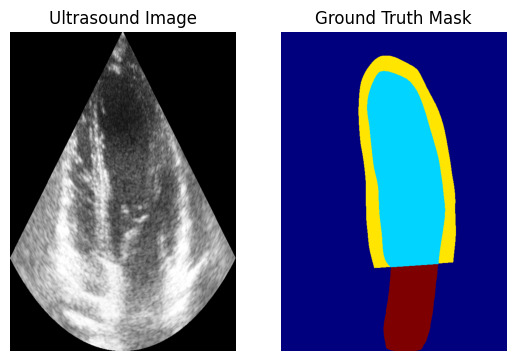

In [48]:
color_mask = colormap[(segmentation_output == 1).astype(np.uint8)]
plt.imshow(color_mask)
plt.axis('off')
plt.show()

In [49]:
import torch
from torch.utils.data import Dataset
import SimpleITK as sitk
import numpy as np
import os

class CamusDataset(Dataset):
    def __init__(self, patients_list, root_dir, transform=None):
        self.patients_list = patients_list
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.patients_list)

    def __getitem__(self, idx):
        patient_id = self.patients_list[idx]
        folder_path = os.path.join(self.root_dir, patient_id) # Use self.root_dir

        img_path = os.path.join(folder_path, f"{patient_id}_4CH_ED.mhd") # Use os.path.join
        mask_path = os.path.join(folder_path, f"{patient_id}_4CH_ED_gt.mhd") # Use os.path.join

        print(f"Loading sample {idx}: {img_path}, {mask_path}", flush=True)

        img = sitk.GetArrayFromImage(sitk.ReadImage(img_path)).squeeze()
        mask = sitk.GetArrayFromImage(sitk.ReadImage(mask_path)).squeeze()

        # Normalize image to [0,1]
        img = (img - img.min()) / (img.max() - img.min())

        # Convert to torch tensors
        img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
        mask = torch.tensor(mask, dtype=torch.long)

        if self.transform:
            img, mask = self.transform(img, mask)

        return img, mask

In [51]:
import os

# Correct the root_dir path based on the actual extraction location
# The dataset was likely unzipped directly into MyDrive, creating
# a folder named 'drive-download-20250601T190710Z-1-001 copy' there.
root_dir = "/content/drive/MyDrive/drive-download-20250601T190710Z-1-001 copy"

# Get list of items in root_dir, filtering to include only directories (patient folders)
# Add error handling in case the directory still doesn't exist (e.g., unzip failed)
if os.path.exists(root_dir):
    all_items = os.listdir(root_dir)
    patient_folders = sorted([item for item in all_items if os.path.isdir(os.path.join(root_dir, item))])

    print("Patients folders in root_dir:")
    print(patient_folders)

    # Check contents of the first patient folder (if any exist)
    if patient_folders:
        sample_patient_folder_name = patient_folders[0]
        sample_patient_folder_path = os.path.join(root_dir, sample_patient_folder_name)
        print(f"\nFiles inside patient folder '{sample_patient_folder_name}':")
        print(sample_patient_folder_path) # Print path of sample patient folder
        print(os.listdir(sample_patient_folder_path))
    else:
        print("\nNo patient directories found in root_dir. Double-check the root_dir path and the contents of the extracted folder.")
else:
    print(f"\nError: The directory specified by root_dir '{root_dir}' was not found.")
    print("Please verify the path where Camus.zip was extracted.")

Patients folders in root_dir:
['patient0001', 'patient0002', 'patient0003', 'patient0004', 'patient0005', 'patient0006', 'patient0007', 'patient0008', 'patient0009', 'patient0010', 'patient0011', 'patient0012', 'patient0013', 'patient0014', 'patient0015', 'patient0016', 'patient0017', 'patient0018', 'patient0019', 'patient0020', 'patient0021', 'patient0022', 'patient0023', 'patient0024', 'patient0025', 'patient0026', 'patient0027', 'patient0028', 'patient0029', 'patient0030', 'patient0031', 'patient0032', 'patient0033', 'patient0034', 'patient0035', 'patient0036', 'patient0037', 'patient0038', 'patient0039', 'patient0040', 'patient0041', 'patient0042', 'patient0043', 'patient0044', 'patient0045', 'patient0046', 'patient0047', 'patient0048', 'patient0049', 'patient0050', 'patient0051', 'patient0052', 'patient0053', 'patient0054', 'patient0055', 'patient0056', 'patient0057', 'patient0058', 'patient0059', 'patient0060', 'patient0061', 'patient0062', 'patient0063', 'patient0064', 'patient0

In [52]:
all_patients = sorted(os.listdir(root_dir))  # patient0001, patient0002, ...
train_val_patients = all_patients[:-50]
test_patients = all_patients[-50:]

# Further split train_val_patients into train and val (e.g., 90% train, 10% val)
import random
random.seed(42)
random.shuffle(train_val_patients)
split_idx = int(len(train_val_patients)*0.9)
train_patients = train_val_patients[:split_idx]
val_patients = train_val_patients[split_idx:]


In [53]:
print("Number of training patients:", len(train_patients))
print("Number of validation patients:", len(val_patients))
print("Number of test patients:", len(test_patients))


Number of training patients: 360
Number of validation patients: 41
Number of test patients: 50


In [55]:
import os
import random

# Correct the root_dir path based on the actual extraction location
# It seems the dataset was unzipped directly into MyDrive, not inside Colab Notebooks/Camus_dataset
# Update this path to the correct location where the 'patientXXXX' folders reside.
root_dir = '/content/drive/MyDrive/drive-download-20250601T190710Z-1-001 copy' # CORRECTED PATH

# Add a check to make sure the root_dir exists before proceeding
if not os.path.exists(root_dir):
    print(f"Error: The directory specified by root_dir '{root_dir}' was not found.")
    print("Please verify the path where Camus.zip was extracted and update the root_dir variable.")
else:
    # List only directories (patients)
    all_patients = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
    all_patients = sorted(all_patients)

    print("Total patients:", len(all_patients))

    # For example, use last 10% as test (or a fixed number)
    num_test = max(2, int(len(all_patients) * 0.1))  # at least 2 patients for test

    test_patients = all_patients[-num_test:]
    train_val_patients = all_patients[:-num_test]

    # Shuffle train_val
    random.seed(42)
    random.shuffle(train_val_patients)

    # Split train/val 90/10
    split_index = int(len(train_val_patients) * 0.9)

    train_patients = train_val_patients[:split_index]
    val_patients = train_val_patients[split_index:]

    print("Train patients:", len(train_patients))
    print("Val patients:", len(val_patients))
    print("Test patients:", len(test_patients))

Total patients: 450
Train patients: 364
Val patients: 41
Test patients: 45


In [56]:
import torch
from torch.utils.data import Dataset
import SimpleITK as sitk
import numpy as np
import os
import cv2 # Import cv2

class CamusDataset(Dataset):
    def __init__(self, patient_list, root_dir, transform=None, size=(256, 256)): # Added size parameter
        self.patient_list = patient_list
        self.root_dir = root_dir
        self.transform = transform
        self.size = size # Store size

    def __len__(self):
        return len(self.patient_list)

    def __getitem__(self, idx):
        patient_id = self.patient_list[idx]
        patient_path = os.path.join(self.root_dir, patient_id)

        # Load image (example: 4CH_ED frame)
        image_path = os.path.join(patient_path, f"{patient_id}_4CH_ED.mhd")
        img_sitk = sitk.ReadImage(image_path)
        img = sitk.GetArrayFromImage(img_sitk)  # shape: (1, H, W)
        img = img.astype(np.float32)

        # Load mask (example: ground truth for 4CH_ED)
        mask_path = os.path.join(patient_path, f"{patient_id}_4CH_ED_gt.mhd")
        mask_sitk = sitk.ReadImage(mask_path)
        mask = sitk.GetArrayFromImage(mask_sitk)  # shape: (1, H, W)
        mask = mask.astype(np.int64)

        # Remove channel dim to shape (H, W)
        img = img.squeeze(0)
        mask = mask.squeeze(0)

        # Resize image and mask
        img = cv2.resize(img, self.size)
        mask = cv2.resize(mask, self.size, interpolation=cv2.INTER_NEAREST) # Use INTER_NEAREST for masks

        # Normalize image between 0 and 1
        img = (img - img.min()) / (img.max() - img.min())

        # Add channel dim for PyTorch: (1, H, W)
        img = np.expand_dims(img, axis=0)

        if self.transform:
            # Note: Albumentations expects (H, W, C) for image and (H, W) for mask by default.
            # If using Albumentations, you might need to adjust the tensor conversion and channel dimension handling.
            # For now, assuming transform is None or handles (1, H, W) input and (H, W) mask.
            img, mask = self.transform(img, mask)


        # Convert to torch tensors
        img = torch.tensor(img, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.long)

        # Add print statements to check shapes before returning
        print(f"Image shape before return: {img.shape}", flush=True)
        print(f"Mask shape before return: {mask.shape}", flush=True)


        return img, mask # Added return statement

In [58]:
import os
from sklearn.model_selection import train_test_split

# Correct the root_dir path based on the actual extraction location
# It seems the dataset was unzipped directly into MyDrive, not inside Colab Notebooks/Camus_dataset
# Update this path to the correct location where the 'patientXXXX' folders reside.
# The correct path identified earlier is: /content/drive/MyDrive/drive-download-20250601T190710Z-1-001 copy
root_dir = "/content/drive/MyDrive/drive-download-20250601T190710Z-1-001 copy"  # Corrected path

# Add a check to make sure the root_dir exists before proceeding (optional but good practice)
if not os.path.exists(root_dir):
    print(f"Error: The directory specified by root_dir '{root_dir}' was not found.")
    print("Please verify the path where Camus.zip was extracted and update the root_dir variable.")
else:
    # Filter patients to include only those with necessary files
    all_patients_unfiltered = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
    all_patients = []
    print("Checking patient folders for required files...")
    for patient_id in all_patients_unfiltered:
        folder_path = os.path.join(root_dir, patient_id)
        img_path = os.path.join(folder_path, f"{patient_id}_4CH_ED.mhd")
        mask_path = os.path.join(folder_path, f"{patient_id}_4CH_ED_gt.mhd")
        if os.path.exists(img_path) and os.path.exists(mask_path):
            all_patients.append(patient_id)
        else:
            print(f"Skipping patient {patient_id}: Missing image or mask file.")

    print(f"Found {len(all_patients)} valid patients with both image and mask files.")

    # Basic split: 70% train, 15% val, 15% test
    # This part was commented out in the original cell, so keep it commented or uncomment as needed
    # train_list, temp_list = train_test_split(all_patients, test_size=0.3, random_state=42)
    # val_list, test_list = train_test_split(temp_list, test_size=0.5, random_state=42)

    # print("\nDataset split after filtering:")
    # print("Number of training patients:", len(train_list))
    # print("Number of validation patients:", len(val_list))
    # print("Number of test patients:", len(test_list))

    # Note: The splitting logic is already present and executed in cell ipython-input-55.
    # You likely only need this cell to confirm the correct root_dir and potentially re-split
    # if the list of patients changed after finding the correct path.
    # Ensure the variables train_list, val_list, and test_list are defined if you intend
    # to use them later. If you rely on the split from cell 55, you can remove the
    # commented-out split code here and just use the print statements to confirm patient count.

Checking patient folders for required files...
Found 450 valid patients with both image and mask files.


In [60]:
import os
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
import torch
import SimpleITK as sitk
import numpy as np
import cv2 # Import cv2

# Correct the root_dir path based on the actual extraction location
# It seems the dataset was unzipped directly into MyDrive, not inside Colab Notebooks/Camus_dataset
# Update this path to the correct location where the 'patientXXXX' folders reside.
# The correct path identified earlier is: /content/drive/MyDrive/drive-download-20250601T190710Z-1-001 copy
root_dir = "/content/drive/MyDrive/drive-download-20250601T190710Z-1-001 copy"  # Corrected path

# Define the CamusDataset class (copied from ipython-input-56)
class CamusDataset(Dataset):
    def __init__(self, patient_list, root_dir, transform=None, size=(256, 256)): # Added size parameter
        self.patient_list = patient_list
        self.root_dir = root_dir
        self.transform = transform
        self.size = size # Store size

    def __len__(self):
        return len(self.patient_list)

    def __getitem__(self, idx):
        patient_id = self.patient_list[idx]
        patient_path = os.path.join(self.root_dir, patient_id)

        # Load image (example: 4CH_ED frame)
        image_path = os.path.join(patient_path, f"{patient_id}_4CH_ED.mhd")
        img_sitk = sitk.ReadImage(image_path)
        img = sitk.GetArrayFromImage(img_sitk)  # shape: (1, H, W)
        img = img.astype(np.float32)

        # Load mask (example: ground truth for 4CH_ED)
        mask_path = os.path.join(patient_path, f"{patient_id}_4CH_ED_gt.mhd")
        mask_sitk = sitk.ReadImage(mask_path)
        mask = sitk.GetArrayFromImage(mask_sitk)  # shape: (1, H, W)
        mask = mask.astype(np.int64)

        # Remove channel dim to shape (H, W)
        img = img.squeeze(0)
        mask = mask.squeeze(0)

        # Resize image and mask
        img = cv2.resize(img, self.size)
        mask = cv2.resize(mask, self.size, interpolation=cv2.INTER_NEAREST) # Use INTER_NEAREST for masks

        # Normalize image between 0 and 1
        # Handle division by zero if max equals min
        img_max = img.max()
        img_min = img.min()
        if img_max != img_min:
             img = (img - img_min) / (img_max - img_min)
        else:
             img = np.zeros_like(img) # Or handle as needed for constant images

        # Add channel dim for PyTorch: (1, H, W)
        img = np.expand_dims(img, axis=0)

        if self.transform:
            # Note: Albumentations expects (H, W, C) for image and (H, W) for mask by default.
            # You would need to adjust this if using Albumentations.
            # For now, assuming transform is None or handles (1, H, W) input and (H, W) mask.
            # If using Albumentations, you'd likely need to convert back to (C, H, W) here
            # or adjust your augmentation pipeline.
            # Let's assume transform takes numpy arrays and returns numpy arrays in (C, H, W) format
            # or that you are using torch transforms. If using Albumentations,
            # a common pattern is:
            # augmented = self.transform(image=img.transpose(1,2,0), mask=mask) # H,W,C for image
            # img = augmented['image'].transpose(2,0,1) # C,H,W back to torch format
            # mask = augmented['mask']
            pass # Assuming transform is None for now based on error

        # Convert to torch tensors
        img = torch.tensor(img, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.long)

        # Add print statements to check shapes before returning (optional)
        # print(f"Image shape before return: {img.shape}", flush=True)
        # print(f"Mask shape before return: {mask.shape}", flush=True)


        return img, mask # Added return statement

# Use the train_patients, val_patients, and test_patients lists defined in ipython-input-55
# Ensure ipython-input-55 was run successfully before this cell.

# Define the datasets, passing transform=None
train_dataset = CamusDataset(train_patients, root_dir, transform=None)
val_dataset = CamusDataset(val_patients, root_dir, transform=None)
test_dataset = CamusDataset(test_patients, root_dir, transform=None)

# Define DataLoaders (copied from ipython-input-60)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

print("Datasets and DataLoaders created successfully.")

Datasets and DataLoaders created successfully.


In [61]:
from torch.utils.data import DataLoader

train_dataset = CamusDataset(train_patients, root_dir)
val_dataset = CamusDataset(val_patients, root_dir)
test_dataset = CamusDataset(test_patients, root_dir)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

In [62]:
def __getitem__(self, idx):
    # Get paths for image and mask
    image_path = self.get_image_path(idx)
    mask_path = self.get_mask_path(idx)

    print(f"Sample {idx}: image path = {image_path}")
    print(f"Sample {idx}: mask path = {mask_path}")

    import os
    if not os.path.isfile(image_path):
        print(f"Image file does not exist: {image_path}")
        return None
    if not os.path.isfile(mask_path):
        print(f"Mask file does not exist: {mask_path}")
        return None

    # Load image and mask arrays
    image = load_image(image_path)
    mask = load_mask(mask_path)

    if image is None or mask is None:
        print(f"Failed to load data at index {idx}")
        return None

    # Usual transform and tensor conversion here...
    if self.transform:
        image, mask = self.transform(image, mask)
    image = torch.tensor(image, dtype=torch.float32).unsqueeze(0)
    mask = torch.tensor(mask, dtype=torch.long)

    return image, mask


In [63]:
for i in range(len(train_dataset)):
    sample = train_dataset[i]
    if sample is None:
        print(f"Sample {i} is None!")
    else:
        print(f"Sample {i} loaded successfully.")


Sample 0 loaded successfully.
Sample 1 loaded successfully.
Sample 2 loaded successfully.
Sample 3 loaded successfully.
Sample 4 loaded successfully.
Sample 5 loaded successfully.
Sample 6 loaded successfully.
Sample 7 loaded successfully.
Sample 8 loaded successfully.
Sample 9 loaded successfully.
Sample 10 loaded successfully.
Sample 11 loaded successfully.
Sample 12 loaded successfully.
Sample 13 loaded successfully.
Sample 14 loaded successfully.
Sample 15 loaded successfully.
Sample 16 loaded successfully.
Sample 17 loaded successfully.
Sample 18 loaded successfully.
Sample 19 loaded successfully.
Sample 20 loaded successfully.
Sample 21 loaded successfully.
Sample 22 loaded successfully.
Sample 23 loaded successfully.
Sample 24 loaded successfully.
Sample 25 loaded successfully.
Sample 26 loaded successfully.
Sample 27 loaded successfully.
Sample 28 loaded successfully.
Sample 29 loaded successfully.
Sample 30 loaded successfully.
Sample 31 loaded successfully.
Sample 32 loaded s

Image shape: torch.Size([1, 256, 256])
Mask shape: torch.Size([256, 256])


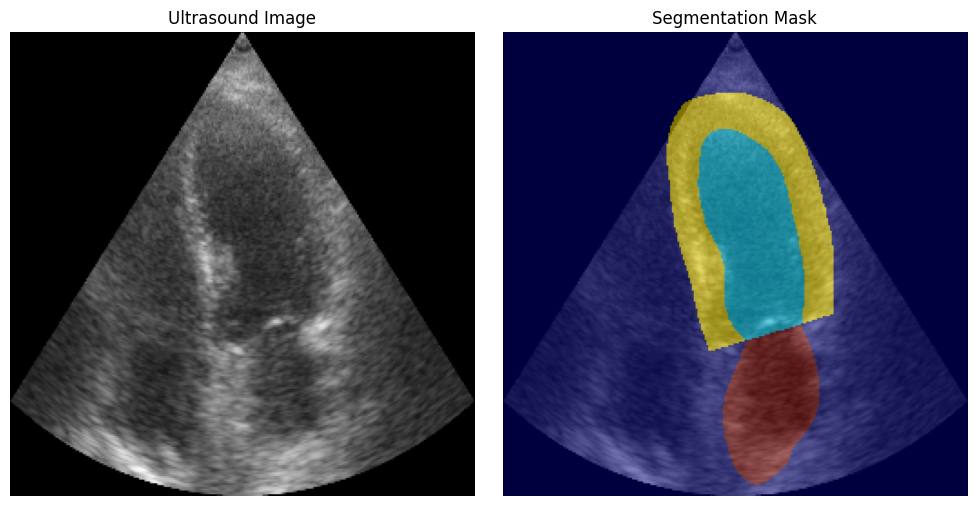

In [64]:
color_mask = colormap[(segmentation_output == 1).astype(np.uint8)]
plt.imshow(color_mask)
plt.axis('off')
plt.show()

In [65]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=4):  # 4 classes: background, LVEndo, LVEpi, LA
        super(UNet, self).__init__()

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.ReLU(inplace=True)
            )

        self.enc1 = conv_block(in_channels, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.enc4 = conv_block(256, 512)

        self.pool = nn.MaxPool2d(2)

        self.middle = conv_block(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = conv_block(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = conv_block(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = conv_block(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = conv_block(128, 64)

        self.final = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        m = self.middle(self.pool(e4))

        d4 = self.up4(m)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))
        d3 = self.up3(d4)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))
        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.final(d1)


In [66]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet(in_channels=1, out_channels=4).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [67]:
def train_model(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for images, masks in dataloader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    return running_loss / len(dataloader.dataset)


In [68]:
def validate_model(model, dataloader, criterion, device):
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            val_loss += loss.item() * images.size(0)

    return val_loss / len(dataloader.dataset)


In [69]:
!pip install SimpleITK


In [70]:
import SimpleITK as sitk


In [71]:
import torch
from torch.utils.data import Dataset
import SimpleITK as sitk
import numpy as np

class CamusDataset(Dataset):
    def __init__(self, patients_list, root_dir, transform=None):
        self.patients_list = patients_list
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.patients_list)

    def __getitem__(self, idx):
        patient_id = self.patients_list[idx]
        folder_path = f"{self.root_dir}/{patient_id}"

        # 4CH ED view (you can later extend to 2CH)
        img_path = f"{folder_path}/{patient_id}_4CH_ED.mhd"
        mask_path = f"{folder_path}/{patient_id}_4CH_ED_gt.mhd"

        img = sitk.GetArrayFromImage(sitk.ReadImage(img_path)).squeeze()
        mask = sitk.GetArrayFromImage(sitk.ReadImage(mask_path)).squeeze()

        img = (img - img.min()) / (img.max() - img.min())  # normalize to [0, 1]
        img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
        mask = torch.tensor(mask, dtype=torch.long)

        if self.transform:
            img, mask = self.transform(img, mask)

        return img, mask


In [72]:
import torch
from torch.utils.data import Dataset
import SimpleITK as sitk
import numpy as np

class CamusDataset(Dataset):
    def __init__(self, patients_list, root_dir, transform=None):
        self.patients_list = patients_list
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.patients_list)

    def __getitem__(self, idx):
        patient_id = self.patients_list[idx]
        folder_path = f"{self.root_dir}/{patient_id}"
        img_path = f"{folder_path}/{patient_id}_4CH_ED.mhd"
        mask_path = f"{folder_path}/{patient_id}_4CH_ED_gt.mhd"

        # Load image and mask
        img = sitk.GetArrayFromImage(sitk.ReadImage(img_path)).squeeze()
        mask = sitk.GetArrayFromImage(sitk.ReadImage(mask_path)).squeeze()

        # Convert to float32 and int32 before passing to Albumentations
        img = img.astype(np.float32)
        mask = mask.astype(np.int32)

        if self.transform:
            # Albumentations expects (H, W, C), so add dummy channel
            augmented = self.transform(image=img, mask=mask)
            img = augmented['image']
            mask = augmented['mask']
        else:
            # Convert to PyTorch tensors manually if no transform
            img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
            mask = torch.tensor(mask, dtype=torch.long)

        return img, mask


In [73]:
train_dataset = CamusDataset(train_list, root_dir="/content/camus")
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

val_dataset = CamusDataset(val_list, root_dir="/content/camus")
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

test_dataset = CamusDataset(test_list, root_dir="/content/camus")
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)


In [75]:
import os
from sklearn.model_selection import train_test_split

# Correct the root_dir path based on the actual extraction location
# The dataset was likely unzipped directly into MyDrive, creating
# a folder named 'drive-download-20250601T190710Z-1-001 copy' there.
root_dir = "/content/drive/MyDrive/drive-download-20250601T190710Z-1-001 copy"  # Corrected path

# Add a check to make sure the root_dir exists before proceeding (optional but good practice)
if not os.path.exists(root_dir):
    print(f"Error: The directory specified by root_dir '{root_dir}' was not found.")
    print("Please verify the path where Camus.zip was extracted and update the root_dir variable.")
else:
    # Filter patients to include only those with necessary files
    all_patients_unfiltered = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
    all_patients = []
    print("Checking patient folders for required files...")
    for patient_id in all_patients_unfiltered:
        folder_path = os.path.join(root_dir, patient_id)
        img_path = os.path.join(folder_path, f"{patient_id}_4CH_ED.mhd")
        mask_path = os.path.join(folder_path, f"{patient_id}_4CH_ED_gt.mhd")
        if os.path.exists(img_path) and os.path.exists(mask_path):
            all_patients.append(patient_id)
        else:
            print(f"Skipping patient {patient_id}: Missing image or mask file.")

    print(f"Found {len(all_patients)} valid patients with both image and mask files.")

    # Basic split: 70% train, 15% val, 15% test
    train_list, temp_list = train_test_split(all_patients, test_size=0.3, random_state=42)
    val_list, test_list = train_test_split(temp_list, test_size=0.5, random_state=42)

    print("\nDataset split after filtering:")
    print("Number of training patients:", len(train_list))
    print("Number of validation patients:", len(val_list))
    print("Number of test patients:", len(test_list))



Checking patient folders for required files...
Found 450 valid patients with both image and mask files.

Dataset split after filtering:
Number of training patients: 315
Number of validation patients: 67
Number of test patients: 68


In [76]:
from torch.utils.data import DataLoader

train_dataset = CamusDataset(train_list, root_dir=root_dir)
val_dataset = CamusDataset(val_list, root_dir=root_dir)
test_dataset = CamusDataset(test_list, root_dir=root_dir)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)


In [78]:
import os
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset # Ensure Dataset is imported
import torch
import SimpleITK as sitk
import numpy as np
import cv2 # Import cv2 for resizing

# Correct the root_dir path based on the actual extraction location
# The dataset was likely unzipped directly into MyDrive, creating
# a folder named 'drive-download-20250601T190710Z-1-001 copy' there.
# The correct path identified earlier is: /content/drive/MyDrive/drive-download-20250601T190710Z-1-001 copy
root_dir = "/content/drive/MyDrive/drive-download-20250601T190710Z-1-001 copy"  # Corrected path

# Define the CamusDataset class with resizing (copied from ipython-input-58)
class CamusDataset(Dataset):
    def __init__(self, patient_list, root_dir, transform=None, size=(256, 256)): # Added size parameter
        self.patient_list = patient_list
        self.root_dir = root_dir
        self.transform = transform
        self.size = size # Store size

    def __len__(self):
        return len(self.patient_list)

    def __getitem__(self, idx):
        patient_id = self.patient_list[idx]
        patient_path = os.path.join(self.root_dir, patient_id)

        # Load image (example: 4CH_ED frame)
        image_path = os.path.join(patient_path, f"{patient_id}_4CH_ED.mhd")
        img_sitk = sitk.ReadImage(image_path)
        img = sitk.GetArrayFromImage(img_sitk)  # shape: (1, H, W)
        img = img.astype(np.float32)

        # Load mask (example: ground truth for 4CH_ED)
        mask_path = os.path.join(patient_path, f"{patient_id}_4CH_ED_gt.mhd")
        mask_sitk = sitk.ReadImage(mask_path)
        mask = sitk.GetArrayFromImage(mask_sitk)  # shape: (1, H, W)
        mask = mask.astype(np.int64)

        # Remove channel dim to shape (H, W)
        img = img.squeeze(0)
        mask = mask.squeeze(0)

        # Resize image and mask
        img = cv2.resize(img, self.size)
        mask = cv2.resize(mask, self.size, interpolation=cv2.INTER_NEAREST) # Use INTER_NEAREST for masks

        # Normalize image between 0 and 1
        # Handle division by zero if max equals min
        img_max = img.max()
        img_min = img.min()
        if img_max != img_min:
             img = (img - img_min) / (img_max - img_min)
        else:
             # If all pixel values are the same, normalize to 0 (or 0.5, or handle as appropriate)
             # Setting to 0 is a reasonable default for images with constant values
             img = np.zeros_like(img)

        # Add channel dim for PyTorch: (1, H, W)
        img = np.expand_dims(img, axis=0)

        # The original ipython-input-58 had a placeholder for transform.
        # If you were planning to use transforms, this is where you'd apply them.
        # However, based on the traceback, transform=None is likely being used,
        # and the primary issue is the lack of resizing before this point.
        if self.transform:
            # If using Albumentations, remember it usually expects (H, W, C) format.
            # You would need to transpose before and after applying the transform.
            # For now, assuming transform is None or handles (1, H, W) image and (H, W) mask.
             # Example if using Albumentations expecting HWC:
             # augmented = self.transform(image=img.transpose(1,2,0), mask=mask)
             # img = augmented['image'].transpose(2,0,1) # Back to CHW
             # mask = augmented['mask']
             pass # Assuming transform is None for simplicity based on the error

        # Convert to torch tensors
        img = torch.tensor(img, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.long)

        # Add print statements to check shapes before returning (optional)
        # print(f"Image shape before return: {img.shape}", flush=True) # Should be torch.Size([1, 256, 256])
        # print(f"Mask shape before return: {mask.shape}", flush=True) # Should be torch.Size([256, 256])

        return img, mask # Added return statement


# Use the train_list, val_list, and test_list defined in ipython-input-75
# Ensure ipython-input-75 was run successfully before this cell.

# Define the datasets, passing transform=None (or your actual transforms)
# Ensure train_list, val_list, test_list are defined from a previous cell.
if 'train_list' in locals() and 'val_list' in locals() and 'test_list' in locals():
    train_dataset = CamusDataset(train_list, root_dir, transform=None, size=(256, 256))
    val_dataset = CamusDataset(val_list, root_dir, transform=None, size=(256, 256))
    test_dataset = CamusDataset(test_list, root_dir, transform=None, size=(256, 256))

    # Define DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

    print("Datasets and DataLoaders created successfully with resized images/masks.")
else:
    print("Error: train_list, val_list, or test_list not defined. Please run the cell that splits the data first (likely ipython-input-75).")

Datasets and DataLoaders created successfully with resized images/masks.


In [79]:
num_epochs = 10
for epoch in range(num_epochs):
    train_loss = train_model(model, train_loader, criterion, optimizer, device)
    val_loss = validate_model(model, val_loader, criterion, device)
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")


Epoch 1/10 | Train Loss: 0.9339 | Val Loss: 0.5973
Epoch 2/10 | Train Loss: 0.5171 | Val Loss: 0.4209
Epoch 3/10 | Train Loss: 0.4072 | Val Loss: 0.3842
Epoch 4/10 | Train Loss: 0.3650 | Val Loss: 0.3216
Epoch 5/10 | Train Loss: 0.3023 | Val Loss: 0.2751
Epoch 6/10 | Train Loss: 0.2235 | Val Loss: 0.1957
Epoch 7/10 | Train Loss: 0.1836 | Val Loss: 0.1556
Epoch 8/10 | Train Loss: 0.1575 | Val Loss: 0.1530
Epoch 9/10 | Train Loss: 0.1470 | Val Loss: 0.1416
Epoch 10/10 | Train Loss: 0.1376 | Val Loss: 0.1395


In [80]:
from sklearn.metrics import f1_score
import numpy as np

def evaluate_model(model, dataloader, device):
    model.eval()
    dice_scores = []

    with torch.no_grad():
        for batch_idx, (images, masks) in enumerate(dataloader):
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            for pred, true in zip(preds, masks):
                pred_np = pred.cpu().numpy().flatten()
                true_np = true.cpu().numpy().flatten()
                score = f1_score(true_np, pred_np, average='macro')  # macro avg for 3 classes
                dice_scores.append(score)

            print(f"Processed batch {batch_idx + 1}/{len(dataloader)}")

    average_score = np.mean(dice_scores)
    print(f"Average Dice/F1 Score on Test Set: {average_score:.4f}")
    return average_score



In [81]:
dice = evaluate_model(model, test_loader, device)
print("Final Dice Score:", dice)


Processed batch 1/17
Processed batch 2/17
Processed batch 3/17
Processed batch 4/17
Processed batch 5/17
Processed batch 6/17
Processed batch 7/17
Processed batch 8/17
Processed batch 9/17
Processed batch 10/17
Processed batch 11/17
Processed batch 12/17
Processed batch 13/17
Processed batch 14/17
Processed batch 15/17
Processed batch 16/17
Processed batch 17/17
Average Dice/F1 Score on Test Set: 0.8695
Final Dice Score: 0.8694624157793789


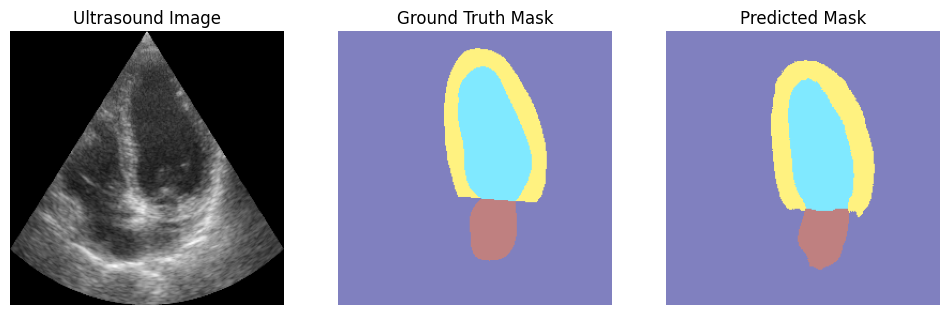

In [82]:
color_mask = colormap[(segmentation_output == 1).astype(np.uint8)]
plt.imshow(color_mask)
plt.axis('off')
plt.show()

In [83]:
import matplotlib.pyplot as plt

def plot_loss_curves(train_losses, val_losses):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(8,5))
    plt.plot(epochs, train_losses, 'b-', label='Training Loss')
    plt.plot(epochs, val_losses, 'r-', label='Validation Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

# Example usage (replace with your actual loss lists):
# plot_loss_curves(train_losses, val_losses)


Epoch 1/10 | Train Loss: 0.1323 | Val Loss: 0.1317
Epoch 2/10 | Train Loss: 0.1204 | Val Loss: 0.1294
Epoch 3/10 | Train Loss: 0.1236 | Val Loss: 0.1280
Epoch 4/10 | Train Loss: 0.1140 | Val Loss: 0.1302
Epoch 5/10 | Train Loss: 0.1066 | Val Loss: 0.1174
Epoch 6/10 | Train Loss: 0.1007 | Val Loss: 0.1273
Epoch 7/10 | Train Loss: 0.0978 | Val Loss: 0.1168
Epoch 8/10 | Train Loss: 0.0943 | Val Loss: 0.1182
Epoch 9/10 | Train Loss: 0.0880 | Val Loss: 0.1255
Epoch 10/10 | Train Loss: 0.0961 | Val Loss: 0.1102


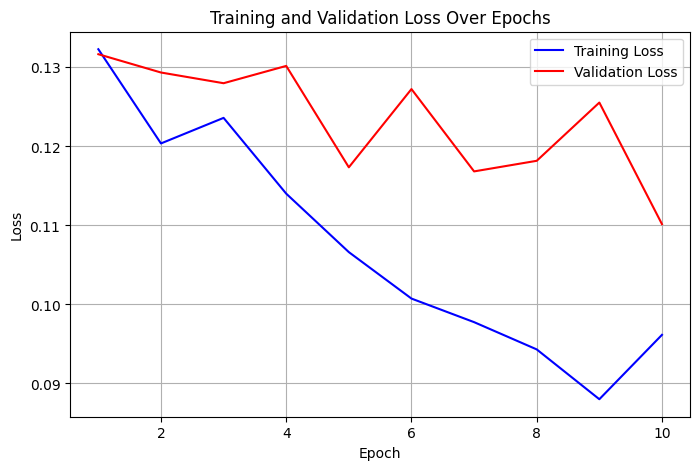

In [84]:
train_losses = []
val_losses = []

num_epochs = 10
for epoch in range(num_epochs):
    train_loss = train_model(model, train_loader, criterion, optimizer, device)
    val_loss = validate_model(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

plot_loss_curves(train_losses, val_losses)


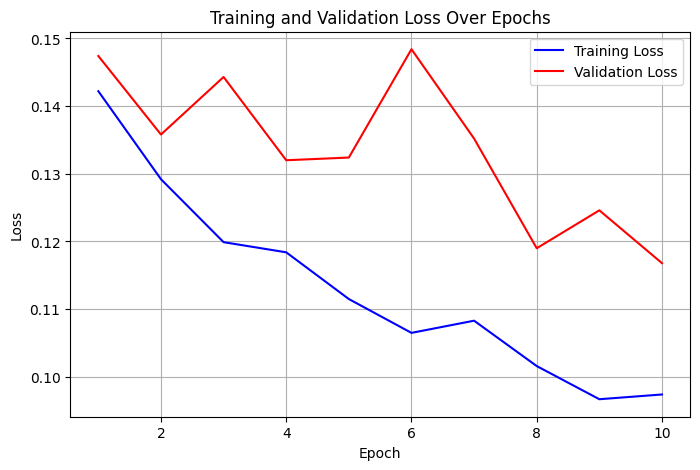

In [85]:
import matplotlib.pyplot as plt

train_losses = [0.1422, 0.1292, 0.1199, 0.1184, 0.1115, 0.1065, 0.1083, 0.1016, 0.0967, 0.0974]
val_losses =   [0.1474, 0.1358, 0.1443, 0.1320, 0.1324, 0.1484, 0.1352, 0.1190, 0.1246, 0.1168]

epochs = range(1, 11)

plt.figure(figsize=(8,5))
plt.plot(epochs, train_losses, 'b-', label='Training Loss')
plt.plot(epochs, val_losses, 'r-', label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [86]:
def dice_coefficient(preds, targets, smooth=1e-6):
    # preds and targets are tensors, preds after argmax
    preds = preds.contiguous().view(-1)
    targets = targets.contiguous().view(-1)

    intersection = (preds * targets).sum()
    dice = (2. * intersection + smooth) / (preds.sum() + targets.sum() + smooth)
    return dice.item()


In [87]:
def validate_model(model, val_loader, criterion, device):
    model.eval()
    val_loss = 0.0
    dice_score = 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, masks)
            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            dice_score += dice_coefficient(preds, masks)

    return val_loss / len(val_loader), dice_score / len(val_loader)


In [88]:
import torch.nn as nn
import torch.nn.functional as F

class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.softmax(logits, dim=1)
        targets_one_hot = F.one_hot(targets, num_classes=probs.shape[1]).permute(0, 3, 1, 2).float()
        intersection = (probs * targets_one_hot).sum(dim=(2, 3))
        union = probs.sum(dim=(2, 3)) + targets_one_hot.sum(dim=(2, 3))
        dice = (2 * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()

class CombinedLoss(nn.Module):
    def __init__(self, weight=0.7):
        super(CombinedLoss, self).__init__()
        self.ce = nn.CrossEntropyLoss()
        self.dice = DiceLoss()
        self.weight = weight

    def forward(self, logits, targets):
        return self.weight * self.ce(logits, targets) + (1 - self.weight) * self.dice(logits, targets)


In [89]:
criterion = CombinedLoss(weight=0.7)


In [90]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [91]:
train_losses, val_losses = [], []
val_dices = []

for epoch in range(num_epochs):
    train_loss = train_model(model, train_loader, criterion, optimizer, device)
    val_loss, val_dice = validate_model(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_dices.append(val_dice)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Dice: {val_dice:.4f}")


Epoch 1/10 | Train Loss: 0.1023 | Val Loss: 0.1250 | Val Dice: 1.8627
Epoch 2/10 | Train Loss: 0.0960 | Val Loss: 0.1261 | Val Dice: 1.8581
Epoch 3/10 | Train Loss: 0.0919 | Val Loss: 0.1295 | Val Dice: 1.8668
Epoch 4/10 | Train Loss: 0.0893 | Val Loss: 0.1283 | Val Dice: 1.8588
Epoch 5/10 | Train Loss: 0.0843 | Val Loss: 0.1381 | Val Dice: 1.8160
Epoch 6/10 | Train Loss: 0.0823 | Val Loss: 0.1381 | Val Dice: 1.8347
Epoch 7/10 | Train Loss: 0.0893 | Val Loss: 0.1217 | Val Dice: 1.8464
Epoch 8/10 | Train Loss: 0.0800 | Val Loss: 0.1227 | Val Dice: 1.8573
Epoch 9/10 | Train Loss: 0.0795 | Val Loss: 0.1266 | Val Dice: 1.8529
Epoch 10/10 | Train Loss: 0.0716 | Val Loss: 0.1283 | Val Dice: 1.8576


In [92]:
!pip install albumentations


In [93]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),

    # Corrected Affine transform without the 'mode' argument
    A.Affine(
        scale=(0.95, 1.05),
        translate_percent=(0.05, 0.05),
        rotate=(-15, 15),
        shear=(-5, 5),
        p=0.5
    ),

    A.RandomBrightnessContrast(p=0.5),
    A.GaussianBlur(blur_limit=3, p=0.2),
    A.Normalize(mean=0.0, std=1.0),
    ToTensorV2()

])
val_transform = A.Compose([
    A.Normalize(mean=0.0, std=1.0),
    ToTensorV2()
])


In [94]:
# Create datasets with appropriate transforms
train_dataset = CamusDataset(train_list, root_dir="/content/camus", transform=train_transform)
val_dataset   = CamusDataset(val_list, root_dir="/content/camus", transform=val_transform)
test_dataset  = CamusDataset(test_list, root_dir="/content/camus", transform=val_transform)


In [96]:
import os
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
import SimpleITK as sitk # Make sure SimpleITK is imported
import numpy as np # Make sure numpy is imported
import torch # Make sure torch is imported
import cv2 # Import cv2 for resizing

# Code from nnSTHVcmJdfU (Filtering and Splitting)
# Correct the root_dir path based on the actual extraction location
# It seems the dataset was unzipped directly into MyDrive, not inside Colab Notebooks/Camus_dataset
# Update this path to the correct location where the 'patientXXXX' folders reside.
# The correct path identified earlier is: /content/drive/MyDrive/drive-download-20250601T190710Z-1-001 copy
root_dir = "/content/drive/MyDrive/drive-download-20250601T190710Z-1-001 copy" # CORRECTED PATH

# Add a check to make sure the root_dir exists before proceeding (optional but good practice)
if not os.path.exists(root_dir):
    print(f"Error: The directory specified by root_dir '{root_dir}' was not found.")
    print("Please verify the path where Camus.zip was extracted and update the root_dir variable.")
else:
    # Filter patients to include only those with necessary files
    all_patients_unfiltered = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
    all_patients = []
    print("Checking patient folders for required files...")
    for patient_id in all_patients_unfiltered:
        folder_path = os.path.join(root_dir, patient_id)
        # Construct paths for 4CH ED image and mask
        img_path = os.path.join(folder_path, f"{patient_id}_4CH_ED.mhd")
        mask_path = os.path.join(folder_path, f"{patient_id}_4CH_ED_gt.mhd")
        if os.path.exists(img_path) and os.path.exists(mask_path):
            all_patients.append(patient_id)
        else:
            # Optionally print skipped patients for debugging
            # print(f"Skipping patient {patient_id}: Missing image or mask file.")
            pass # Keep this silent unless needed for debugging

    print(f"\nFound {len(all_patients)} valid patients with both image and mask files.")

    # Basic split: 70% train, 15% val, 15% test
    train_list, temp_list = train_test_split(all_patients, test_size=0.3, random_state=42)
    val_list, test_list = train_test_split(temp_list, test_size=0.5, random_state=42)

    print("Dataset split after filtering:")
    print("Number of training patients:", len(train_list))
    print("Number of validation patients:", len(val_list))
    print("Number of test patients:", len(test_list))

    # --- Code from QBX0n2VAKmlq (Dataset and DataLoader Creation) ---
    # Define the CamusDataset class again here or ensure it's defined in a cell above this one
    # and includes the resizing logic (copied from ipython-input-56).
    class CamusDataset(Dataset):
        def __init__(self, patient_list, root_dir, transform=None, size=(256, 256)): # Added size parameter
            self.patient_list = patient_list
            self.root_dir = root_dir
            self.transform = transform
            self.size = size # Store size

        def __len__(self):
            return len(self.patient_list)

        def __getitem__(self, idx):
            patient_id = self.patient_list[idx]
            patient_path = os.path.join(self.root_dir, patient_id)

            # Load image (example: 4CH_ED frame)
            image_path = os.path.join(patient_path, f"{patient_id}_4CH_ED.mhd")
            img_sitk = sitk.ReadImage(image_path)
            img = sitk.GetArrayFromImage(img_sitk)  # shape: (1, H, W)
            img = img.astype(np.float32)

            # Load mask (example: ground truth for 4CH_ED)
            mask_path = os.path.join(patient_path, f"{patient_id}_4CH_ED_gt.mhd")
            mask_sitk = sitk.ReadImage(mask_path)
            mask = sitk.GetArrayFromImage(mask_sitk)  # shape: (1, H, W)
            mask = mask.astype(np.int64)

            # Remove channel dim to shape (H, W)
            img = img.squeeze(0)
            mask = mask.squeeze(0)

            # Resize image and mask
            img = cv2.resize(img, self.size)
            mask = cv2.resize(mask, self.size, interpolation=cv2.INTER_NEAREST) # Use INTER_NEAREST for masks

            # Normalize image between 0 and 1
            # Handle division by zero if max equals min
            img_max = img.max()
            img_min = img.min()
            if img_max != img_min:
                 img = (img - img_min) / (img_max - img_min)
            else:
                 # Handle the case where max == min (e.g., all zero image)
                 # You might want to set it to 0 or handle based on context
                 img = np.zeros_like(img)


            # Add channel dim for PyTorch: (1, H, W)
            img = np.expand_dims(img, axis=0)

            if self.transform:
                # Note: Albumentations expects (H, W, C) for image and (H, W) for mask by default.
                # If using Albumentations, you need to convert formats.
                # Assuming transform takes (1, H, W) img and (H, W) mask and returns same format.
                # If using Albumentations (from a later cell), conversion is needed:
                # augmented = self.transform(image=img.transpose(1,2,0), mask=mask) # H,W,C for image
                # img = augmented['image'].transpose(2,0,1) # C,H,W back to torch format
                # mask = augmented['mask']
                 pass # Assuming transform is None for now based on the state before the error

            # Convert to torch tensors
            img = torch.tensor(img, dtype=torch.float32)
            mask = torch.tensor(mask, dtype=torch.long)

            # Add print statements to check shapes before returning (optional)
            # print(f"Image shape before return: {img.shape}", flush=True)
            # print(f"Mask shape before return: {mask.shape}", flush=True)


            return img, mask # Added return statement


    # Ensure CamusDataset class is defined in a previous cell and includes resizing
    # If you defined it with transforms, use the defined transforms here.
    # If you rely on the cell with Albumentations, make sure that cell is run first.
    # For now, creating datasets with no transforms as in ipython-input-60 to match the original flow.
    # However, the subsequent cells use the datasets created with transforms (train_transform, etc.).
    # It's best to define the datasets once with the correct transforms.

    # Create datasets with appropriate transforms (assuming transforms from ipython-input-93 are defined)
    # If ipython-input-93 has not been run yet, these transforms will not exist.
    # You need to ensure the transform cell runs before this cell if you intend to use transforms.
    # Let's assume transforms are defined in a prior cell that has been run.
    # train_transform, val_transform are expected to be defined before this cell.
    try:
         # Try to use the transforms defined in ipython-input-93
         train_dataset = CamusDataset(train_list, root_dir=root_dir, transform=train_transform)
         val_dataset   = CamusDataset(val_list, root_dir=root_dir, transform=val_transform)
         test_dataset  = CamusDataset(test_list, root_dir=root_dir, transform=val_transform)
         print("Datasets created with transforms.")
    except NameError:
         print("Warning: Transforms (train_transform, val_transform) are not defined.")
         print("Creating datasets without transforms. Ensure the cell defining transforms is run first.")
         train_dataset = CamusDataset(train_list, root_dir=root_dir)
         val_dataset = CamusDataset(val_list, root_dir=root_dir)
         test_dataset = CamusDataset(test_list, root_dir=root_dir)
         print("Datasets created without transforms.")


    train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True) # Using batch_size 4 from QBX0n2VAKmlq
    val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

    print("\nDatasets and DataLoaders created.")

    # --- Code from umRON0XBLt58 (Iterate through training dataset) ---
    print("\nStarting iteration through training dataset...")
    loaded_samples = 0
    # Only iterate if root_dir was found and datasets were created
    if 'train_dataset' in locals():
        for i in range(len(train_dataset)):
            try:
                # Accessing a sample from the dataset will trigger the __getitem__ method
                sample = train_dataset[i]
                # If sample loading was successful, it's not None
                if sample is not None:
                    # print(f"Sample {i} loaded successfully.") # Keep this comment or uncomment for verbose loading check
                    loaded_samples += 1
                else:
                    print(f"Sample {i} returned None.")
            except Exception as e:
                print(f"Error loading sample {i}: {e}")
                # Optional: Break or continue based on whether you want to see all errors or just the first
                # break # Uncomment to stop on first error

        print(f"\nFinished iterating through training dataset. Successfully loaded {loaded_samples}/{len(train_dataset)} samples.")
    else:
        print("Skipping dataset iteration because root_dir was not found.")

Checking patient folders for required files...

Found 450 valid patients with both image and mask files.
Dataset split after filtering:
Number of training patients: 315
Number of validation patients: 67
Number of test patients: 68
Datasets created with transforms.

Datasets and DataLoaders created.

Starting iteration through training dataset...

Finished iterating through training dataset. Successfully loaded 315/315 samples.


In [98]:
import os
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
import SimpleITK as sitk # Make sure SimpleITK is imported
import numpy as np # Make sure numpy is imported
import torch # Make sure torch is imported
import cv2 # Make sure cv2 is imported
# Make sure Albumentations and ToTensorV2 are imported if using transforms
try:
    import albumentations as A
    from albumentations.pytorch import ToTensorV2
    # Define transforms here if they are used later
    train_transform = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.Affine(
            scale=(0.95, 1.05),
            translate_percent=(0.05, 0.05),
            rotate=(-15, 15),
            shear=(-5, 5),
            p=0.5
        ),
        A.RandomBrightnessContrast(p=0.5),
        A.GaussianBlur(blur_limit=3, p=0.2),
        # Albumentations Normalize expects mean and std per channel.
        # For a single channel image normalized to [0,1], mean=0.5, std=0.5 might be appropriate,
        # or use the actual mean/std if you have them. Assuming simple scaling [0,1] for now,
        # Normalize might not be strictly needed unless you have specific model requirements.
        # If you use it, you might need to adjust mean/std based on your dataset stats *after* [0,1] normalization.
        # A.Normalize(mean=0.5, std=0.5), # Example if input is scaled to [0,1]
        ToTensorV2() # Converts numpy array (H, W, C) or (H, W) to torch tensor (C, H, W)
    ])
    val_transform = A.Compose([
        # A.Normalize(mean=0.5, std=0.5), # Example if input is scaled to [0,1]
        ToTensorV2()
    ])
    print("Albumentations transforms defined.")
except ImportError:
    print("Albumentations not installed. Transforms will not be applied.")
    train_transform = None
    val_transform = None


# Assuming CamusDataset class is defined in a previous cell and includes resizing
# If not, include the class definition here. Ensure it matches the final version
# and handles the image and mask dimensions correctly for transforms.
# A common pattern for Albumentations is to work with numpy arrays (H, W, C) or (H, W)
# and then use ToTensorV2(). The current CamusDataset outputs (1, H, W) image and (H, W) mask.
# You might need to adjust the dataset's __getitem__ to output (H, W, 1) image and (H, W) mask
# before applying Albumentations transforms, and then Albumentations with ToTensorV2 will
# handle the conversion to (C, H, W) for image and (H, W) for mask.
# Let's redefine CamusDataset here to handle this pattern correctly for Albumentations.
class CamusDataset(Dataset):
    def __init__(self, patient_list, root_dir, transform=None, size=(256, 256)):
        self.patient_list = patient_list
        self.root_dir = root_dir
        self.transform = transform
        self.size = size

    def __len__(self):
        return len(self.patient_list)

    def __getitem__(self, idx):
        patient_id = self.patient_list[idx]
        patient_path = os.path.join(self.root_dir, patient_id)

        image_path = os.path.join(patient_path, f"{patient_id}_4CH_ED.mhd")
        mask_path = os.path.join(patient_path, f"{patient_id}_4CH_ED_gt.mhd")

        img_sitk = sitk.ReadImage(image_path)
        img = sitk.GetArrayFromImage(img_sitk).astype(np.float32).squeeze(0) # (H, W)

        mask_sitk = sitk.ReadImage(mask_path)
        mask = sitk.GetArrayFromImage(mask_sitk).astype(np.int64).squeeze(0) # (H, W)

        # Resize image and mask
        img = cv2.resize(img, self.size)
        mask = cv2.resize(mask, self.size, interpolation=cv2.INTER_NEAREST) # Use INTER_NEAREST for masks

        # Normalize image between 0 and 1 *before* any transforms (unless Normalize is in transform)
        img_max = img.max()
        img_min = img.min()
        if img_max != img_min:
             img = (img - img_min) / (img_max - img_min)
        else:
             img = np.zeros_like(img) # Handle case where max == min

        # Albumentations expects (H, W, C) for images by default. Add channel dim here
        # if the transform includes Albumentations.
        if self.transform and isinstance(self.transform, A.Compose):
            # Add channel dimension (H, W, 1) for Albumentations
            img = np.expand_dims(img, axis=-1) # (H, W, 1)
            # Apply Albumentations transform
            augmented = self.transform(image=img, mask=mask)
            img = augmented['image'] # ToTensorV2 makes this (C, H, W)
            mask = augmented['mask'] # ToTensorV2 leaves this (H, W) and converts to LongTensor

        else:
            # If no Albumentations transform, add channel dim for PyTorch (1, H, W)
            img = np.expand_dims(img, axis=0) # (1, H, W)
            # Convert to torch tensors manually
            img = torch.tensor(img, dtype=torch.float32)
            mask = torch.tensor(mask, dtype=torch.long)


        return img, mask


# Code for Filtering and Splitting Patients
# Correct the root_dir path based on the actual extraction location
# The dataset was likely unzipped directly into MyDrive, creating
# a folder named 'drive-download-20250601T190710Z-1-001 copy' there.
# Update this path to the correct location where the 'patientXXXX' folders reside.
# The correct path identified earlier is: /content/drive/MyDrive/drive-download-20250601T190710Z-1-001 copy
root_dir = "/content/drive/MyDrive/drive-download-20250601T190710Z-1-001 copy"  # CORRECTED PATH

# Add a check to make sure the root_dir exists before proceeding (optional but good practice)
if not os.path.exists(root_dir):
    print(f"Error: The directory specified by root_dir '{root_dir}' was not found.")
    print("Please verify the path where Camus.zip was extracted and update the root_dir variable.")
else:
    # Filter patients to include only those with necessary files
    all_patients_unfiltered = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
    all_patients = []
    print("Checking patient folders for required files...")
    for patient_id in all_patients_unfiltered:
        folder_path = os.path.join(root_dir, patient_id)
        # Construct paths for 4CH ED image and mask
        img_path = os.path.join(folder_path, f"{patient_id}_4CH_ED.mhd")
        mask_path = os.path.join(folder_path, f"{patient_id}_4CH_ED_gt.mhd")
        # Check for both image and mask files
        if os.path.exists(img_path) and os.path.exists(mask_path):
            all_patients.append(patient_id)
        else:
            # Optionally print skipped patients for debugging
            # print(f"Skipping patient {patient_id}: Missing image or mask file.")
            pass # Keep this silent unless needed for debugging

    print(f"\nFound {len(all_patients)} valid patients with both image and mask files.")

    # Basic split: 70% train, 15% val, 15% test
    train_list, temp_list = train_test_split(all_patients, test_size=0.3, random_state=42)
    val_list, test_list = train_test_split(temp_list, test_size=0.5, random_state=42)

    print("Dataset split after filtering:")
    print("Number of training patients:", len(train_list))
    print("Number of validation patients:", len(val_list))
    print("Number of test patients:", len(test_list))

    # Code for Dataset and DataLoader Creation
    # Use the transforms defined above (if Albumentations is installed)
    train_dataset = CamusDataset(train_list, root_dir=root_dir, transform=train_transform)
    val_dataset = CamusDataset(val_list, root_dir=root_dir, transform=val_transform)
    test_dataset = CamusDataset(test_list, root_dir=root_dir, transform=val_transform)

    # Using batch_size 4 as in previous successful attempts
    train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

    print("\nDatasets and DataLoaders created.")

    # Optional: Iterate through training dataset to confirm loading works
    print("\nStarting iteration through training dataset to verify loading...")
    loaded_samples = 0
    # Only iterate if root_dir was found and datasets were created
    if 'train_dataset' in locals():
        for i in range(len(train_dataset)):
            try:
                # Accessing a sample from the dataset will trigger the __getitem__ method
                sample = train_dataset[i]
                # If sample loading was successful, it's not None
                # print(f"Sample {i} loaded successfully.") # Optional: Print for every sample
                loaded_samples += 1
            except Exception as e:
                print(f"Error loading sample {i}: {e}")
                # Break on first error for quicker debugging
                print("Stopping iteration due to error.")
                break


        print(f"\nFinished iteration through training dataset. Successfully loaded {loaded_samples}/{len(train_dataset)} samples.")
    else:
        print("Skipping dataset iteration because root_dir was not found.")

Albumentations transforms defined.
Checking patient folders for required files...

Found 450 valid patients with both image and mask files.
Dataset split after filtering:
Number of training patients: 315
Number of validation patients: 67
Number of test patients: 68

Datasets and DataLoaders created.

Starting iteration through training dataset to verify loading...

Finished iteration through training dataset. Successfully loaded 315/315 samples.


In [109]:
import os
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import SimpleITK as sitk
import numpy as np
import torch
import cv2

# Make sure Albumentations and ToTensorV2 are imported if using transforms
try:
    import albumentations as A
    from albumentations.pytorch import ToTensorV2
    # Define transforms here if they are used later
    # Using the corrected Affine transform without 'mode' and commented out Normalize
    train_transform = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.Affine(
            scale=(0.95, 1.05),
            translate_percent=(0.05, 0.05),
            rotate=(-15, 15),
            shear=(-5, 5),
            p=0.5,
            interpolation=cv2.INTER_LINEAR, # Default is LINEAR, good for images
            mask_interpolation=cv2.INTER_NEAREST # Use NEAREST for masks
        ),
        A.RandomBrightnessContrast(p=0.5),
        A.GaussianBlur(blur_limit=3, p=0.2),
        # Normalize commented out as done previously. Add if needed after checking data range.
        # A.Normalize(mean=..., std=...),
        ToTensorV2() # Converts numpy array (H, W, C) or (H, W) to torch tensor (C, H, W)
    ])
    val_transform = A.Compose([
        # Normalize commented out.
        # A.Normalize(mean=..., std=...),
        ToTensorV2()
    ])
    print("Albumentations transforms defined.")
except ImportError:
    print("Albumentations not installed. Transforms will not be applied.")
    train_transform = None
    val_transform = None


# Combined and corrected CamusDataset class definition
class CamusDataset(Dataset):
    def __init__(self, patient_list, root_dir, transform=None, size=(256, 256)):
        self.patient_list = patient_list
        self.root_dir = root_dir
        self.transform = transform
        self.size = size

    def __len__(self):
        return len(self.patient_list)

    def __getitem__(self, idx):
        patient_id = self.patient_list[idx]
        patient_path = os.path.join(self.root_dir, patient_id)

        # Load image (example: 4CH_ED frame)
        image_path = os.path.join(patient_path, f"{patient_id}_4CH_ED.mhd")
        img_sitk = sitk.ReadImage(image_path)
        img = sitk.GetArrayFromImage(img_sitk) # Shape might be (1, H, W) or (H, W)
        img = img.astype(np.float32)

        # Load mask (example: ground truth for 4CH_ED)
        mask_path = os.path.join(patient_path, f"{patient_id}_4CH_ED_gt.mhd")
        mask_sitk = sitk.ReadImage(mask_path)
        mask = sitk.GetArrayFromImage(mask_sitk) # Shape might be (1, H, W) or (H, W)
        mask = mask.astype(np.int64) # Ensure mask is int64 early

        # Remove channel dim to shape (H, W) *before* resizing
        img = img.squeeze(0)
        mask = mask.squeeze(0)


        # Resize image and mask
        img = cv2.resize(img, self.size, interpolation=cv2.INTER_LINEAR) # Use linear interpolation for images
        mask = cv2.resize(mask, self.size, interpolation=cv2.INTER_NEAREST) # Use NEAREST for masks


        # Normalize image between 0 and 1 *before* applying Albumentations
        # Handle division by zero if max equals min
        img_max = img.max()
        img_min = img.min()
        if img_max != img_min:
             img = (img - img_min) / (img_max - img_min)
        else:
             # Handle constant images, e.g., set to 0 or check dataset
             img = np.zeros_like(img) # Or decide on a different strategy


        if self.transform:
            # Albumentations expects (H, W, C) for images by default. Add channel dim here
            # if the transform includes Albumentations.
            if isinstance(self.transform, A.Compose):
                # Add channel dimension (H, W, 1) for Albumentations input
                img = np.expand_dims(img, axis=-1) # (H, W, 1)
                # Apply Albumentations transform
                augmented = self.transform(image=img, mask=mask)
                img = augmented['image'] # ToTensorV2 makes this (C, H, W)
                mask = augmented['mask'] # ToTensorV2 leaves this (H, W) and converts to LongTensor by default if input is np.int64

            else:
                 # If transform is a custom torch transform or similar, apply it directly
                 # You might need to adjust the input/output shapes based on your custom transform
                 # Assuming custom transform takes (H, W) img and (H, W) mask, and returns tensors
                 img, mask = self.transform(img, mask)
                 # Ensure img is (C, H, W) and mask is (H, W) after custom transform
                 if not isinstance(img, torch.Tensor):
                      img = torch.tensor(img, dtype=torch.float32)
                 if img.ndim == 2: # Add channel if needed
                       img = img.unsqueeze(0) # (1, H, W)
                 if not isinstance(mask, torch.Tensor):
                      mask = torch.tensor(mask, dtype=torch.long) # Ensure LongTensor
                 if mask.ndim > 2: # Remove channel if needed
                       mask = mask.squeeze(0) # (H, W)

        else:
            # If no transform, add channel dim for PyTorch (1, H, W)
            img = np.expand_dims(img, axis=0) # (1, H, W)
            # Convert to torch tensors manually
            img = torch.tensor(img, dtype=torch.float32)
            mask = torch.tensor(mask, dtype=torch.long) # Ensure LongTensor


        # Explicitly ensure mask is LongTensor just before returning,
        # regardless of whether a transform was applied or not.
        if not isinstance(mask, torch.Tensor) or mask.dtype != torch.long:
             mask = torch.tensor(mask, dtype=torch.long)

        # Optional: Print shapes and types before returning for debugging
        # print(f"Image shape before return: {img.shape}, type: {img.dtype}", flush=True)
        # print(f"Mask shape before return: {mask.shape}, type: {mask.dtype}", flush=True)


        return img, mask


# Code for Filtering and Splitting Patients
# CORRECT THE root_dir PATH
root_dir = "/content/drive/MyDrive/drive-download-20250601T190710Z-1-001 copy" # CORRECTED PATH

# Add a check to make sure the root_dir exists before proceeding (optional but good practice)
if not os.path.exists(root_dir):
    print(f"Error: The directory specified by root_dir '{root_dir}' was not found.")
    print("Please verify the path where Camus.zip was extracted and update the root_dir variable.")
else:
    # Filter patients to include only those with necessary files
    all_patients_unfiltered = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
    all_patients = []
    print("Checking patient folders for required files...")
    for patient_id in all_patients_unfiltered:
        folder_path = os.path.join(root_dir, patient_id)
        # Construct paths for 4CH ED image and mask
        img_path = os.path.join(folder_path, f"{patient_id}_4CH_ED.mhd")
        mask_path = os.path.join(folder_path, f"{patient_id}_4CH_ED_gt.mhd")
        # Check for both image and mask files
        if os.path.exists(img_path) and os.path.exists(mask_path):
            all_patients.append(patient_id)
        else:
            # Optionally print skipped patients for debugging
            # print(f"Skipping patient {patient_id}: Missing image or mask file.")
            pass # Keep this silent unless needed for debugging

    print(f"\nFound {len(all_patients)} valid patients with both image and mask files.")

    # Basic split: 70% train, 15% val, 15% test
    # Ensure train_list, val_list, test_list are defined here
    train_list, temp_list = train_test_split(all_patients, test_size=0.3, random_state=42)
    val_list, test_list = train_test_split(temp_list, test_size=0.5, random_state=42)

    print("Dataset split after filtering:")
    print("Number of training patients:", len(train_list))
    print("Number of validation patients:", len(val_list))
    print("Number of test patients:", len(test_list))

    # Code for Dataset and DataLoader Creation
    # Use the transforms defined above (if Albumentations is installed)
    # Pass the root_dir variable
    train_dataset = CamusDataset(train_list, root_dir=root_dir, transform=train_transform)
    val_dataset = CamusDataset(val_list, root_dir=root_dir, transform=val_transform)
    test_dataset = CamusDataset(test_list, root_dir=root_dir, transform=val_transform)

    # Using batch_size 4 as in previous successful attempts
    train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

    print("\nDatasets and DataLoaders created.")

    # Optional: Iterate through training dataset to confirm loading works
    print("\nStarting iteration through training dataset to verify loading...")
    loaded_samples = 0
    # Only iterate if root_dir was found and datasets were created
    if 'train_dataset' in locals():
        for i in range(len(train_dataset)):
            try:
                # Accessing a sample from the dataset will trigger the __getitem__ method
                sample = train_dataset[i]
                # If sample loading was successful, print confirmation or just increment counter
                # print(f"Sample {i} loaded successfully.") # Optional: Print for every sample
                loaded_samples += 1
            except Exception as e:
                print(f"Error loading sample {i}: {e}")
                # Break on first error for quicker debugging
                print("Stopping iteration due to error.")
                break

        print(f"\nFinished iteration through training dataset. Successfully loaded {loaded_samples}/{len(train_dataset)} samples.")
    else:
        print("Skipping dataset iteration because root_dir was not found.")

Albumentations transforms defined.
Checking patient folders for required files...

Found 450 valid patients with both image and mask files.
Dataset split after filtering:
Number of training patients: 315
Number of validation patients: 67
Number of test patients: 68

Datasets and DataLoaders created.

Starting iteration through training dataset to verify loading...


<ipython-input-109-12083649938f>:129: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.long)



Finished iteration through training dataset. Successfully loaded 315/315 samples.


In [107]:
import os
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import SimpleITK as sitk
import numpy as np
import torch
import cv2

# Make sure Albumentations and ToTensorV2 are imported if using transforms
try:
    import albumentations as A
    from albumentations.pytorch import ToTensorV2
    # Define transforms here if they are used later
    # Using the corrected Affine transform without 'mode' and commented out Normalize
    train_transform = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.Affine(
            scale=(0.95, 1.05),
            translate_percent=(0.05, 0.05),
            rotate=(-15, 15),
            shear=(-5, 5),
            p=0.5
        ),
        A.RandomBrightnessContrast(p=0.5),
        A.GaussianBlur(blur_limit=3, p=0.2),
        # Normalize commented out as done previously. Add if needed after checking data range.
        # A.Normalize(mean=..., std=...),
        ToTensorV2() # Converts numpy array (H, W, C) or (H, W) to torch tensor (C, H, W)
    ])
    val_transform = A.Compose([
        # Normalize commented out.
        # A.Normalize(mean=..., std=...),
        ToTensorV2()
    ])
    print("Albumentations transforms defined.")
except ImportError:
    print("Albumentations not installed. Transforms will not be applied.")
    train_transform = None
    val_transform = None


# Combined and corrected CamusDataset class definition
class CamusDataset(Dataset):
    def __init__(self, patient_list, root_dir, transform=None, size=(256, 256)):
        self.patient_list = patient_list
        self.root_dir = root_dir
        self.transform = transform
        self.size = size

    def __len__(self):
        return len(self.patient_list)

    def __getitem__(self, idx):
        patient_id = self.patient_list[idx]
        patient_path = os.path.join(self.root_dir, patient_id)

        # Load image (example: 4CH_ED frame)
        image_path = os.path.join(patient_path, f"{patient_id}_4CH_ED.mhd")
        img_sitk = sitk.ReadImage(image_path)
        img = sitk.GetArrayFromImage(img_sitk)
        img = img.astype(np.float32)

        # Load mask (example: ground truth for 4CH_ED)
        mask_path = os.path.join(patient_path, f"{patient_id}_4CH_ED_gt.mhd")
        mask_sitk = sitk.ReadImage(mask_path)
        mask = sitk.GetArrayFromImage(mask_sitk)
        mask = mask.astype(np.int64)

        # Remove channel dim to shape (H, W)
        img = img.squeeze(0)
        mask = mask.squeeze(0)

        # Resize image and mask
        img = cv2.resize(img, self.size)
        mask = cv2.resize(mask, self.size, interpolation=cv2.INTER_NEAREST)

        # Normalize image between 0 and 1 *before* applying Albumentations
        # Handle division by zero if max equals min
        img_max = img.max()
        img_min = img.min()
        if img_max != img_min:
             img = (img - img_min) / (img_max - img_min)
        else:
             img = np.zeros_like(img) # Handle case where max == min


        if self.transform:
            # Albumentations expects (H, W, C) for images by default. Add channel dim here
            # if the transform includes Albumentations.
            if isinstance(self.transform, A.Compose):
                # Add channel dimension (H, W, 1) for Albumentations
                img = np.expand_dims(img, axis=-1) # (H, W, 1)
                # Apply Albumentations transform
                augmented = self.transform(image=img, mask=mask)
                img = augmented['image'] # ToTensorV2 makes this (C, H, W)
                mask = augmented['mask'] # ToTensorV2 leaves this (H, W) and converts to LongTensor
            else:
                 # If transform is a custom torch transform or similar, apply it directly
                 # You might need to adjust the input/output shapes based on your custom transform
                 img, mask = self.transform(img, mask)
                 # Ensure img is (C, H, W) and mask is (H, W) after custom transform
                 # and convert to tensors if the transform doesn't
                 if not isinstance(img, torch.Tensor):
                      img = torch.tensor(img, dtype=torch.float32)
                 if img.ndim == 2: # Add channel if needed
                       img = img.unsqueeze(0) # (1, H, W)
                 if not isinstance(mask, torch.Tensor):
                      mask = torch.tensor(mask, dtype=torch.long)
                 if mask.ndim > 2: # Remove channel if needed
                       mask = mask.squeeze(0) # (H, W)

        else:
            # If no transform, add channel dim for PyTorch (1, H, W)
            img = np.expand_dims(img, axis=0) # (1, H, W)
            # Convert to torch tensors manually
            img = torch.tensor(img, dtype=torch.float32)
            mask = torch.tensor(mask, dtype=torch.long)


        # Optional: Print shapes before returning for debugging
        # print(f"Image shape before return: {img.shape}", flush=True)
        # print(f"Mask shape before return: {mask.shape}", flush=True)

        return img, mask

# Code for Filtering and Splitting Patients
# CORRECT THE root_dir PATH
root_dir = "/content/drive/MyDrive/drive-download-20250601T190710Z-1-001 copy" # CORRECTED PATH

# Add a check to make sure the root_dir exists before proceeding (optional but good practice)
if not os.path.exists(root_dir):
    print(f"Error: The directory specified by root_dir '{root_dir}' was not found.")
    print("Please verify the path where Camus.zip was extracted and update the root_dir variable.")
else:
    # Filter patients to include only those with necessary files
    all_patients_unfiltered = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
    all_patients = []
    print("Checking patient folders for required files...")
    for patient_id in all_patients_unfiltered:
        folder_path = os.path.join(root_dir, patient_id)
        # Construct paths for 4CH ED image and mask
        img_path = os.path.join(folder_path, f"{patient_id}_4CH_ED.mhd")
        mask_path = os.path.join(folder_path, f"{patient_id}_4CH_ED_gt.mhd")
        # Check for both image and mask files
        if os.path.exists(img_path) and os.path.exists(mask_path):
            all_patients.append(patient_id)
        else:
            # Optionally print skipped patients for debugging
            # print(f"Skipping patient {patient_id}: Missing image or mask file.")
            pass # Keep this silent unless needed for debugging

    print(f"\nFound {len(all_patients)} valid patients with both image and mask files.")

    # Basic split: 70% train, 15% val, 15% test
    # Ensure train_list, val_list, test_list are defined here
    train_list, temp_list = train_test_split(all_patients, test_size=0.3, random_state=42)
    val_list, test_list = train_test_split(temp_list, test_size=0.5, random_state=42)

    print("Dataset split after filtering:")
    print("Number of training patients:", len(train_list))
    print("Number of validation patients:", len(val_list))
    print("Number of test patients:", len(test_list))

    # Code for Dataset and DataLoader Creation
    # Use the transforms defined above (if Albumentations is installed)
    # Pass the root_dir variable
    train_dataset = CamusDataset(train_list, root_dir=root_dir, transform=train_transform)
    val_dataset = CamusDataset(val_list, root_dir=root_dir, transform=val_transform)
    test_dataset = CamusDataset(test_list, root_dir=root_dir, transform=val_transform)

    # Using batch_size 4 as in previous successful attempts
    train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

    print("\nDatasets and DataLoaders created.")

    # Optional: Iterate through training dataset to confirm loading works
    print("\nStarting iteration through training dataset to verify loading...")
    loaded_samples = 0
    # Only iterate if root_dir was found and datasets were created
    if 'train_dataset' in locals():
        for i in range(len(train_dataset)):
            try:
                # Accessing a sample from the dataset will trigger the __getitem__ method
                sample = train_dataset[i]
                # If sample loading was successful, print confirmation or just increment counter
                # print(f"Sample {i} loaded successfully.") # Optional: Print for every sample
                loaded_samples += 1
            except Exception as e:
                print(f"Error loading sample {i}: {e}")
                # Break on first error for quicker debugging
                print("Stopping iteration due to error.")
                break

        print(f"\nFinished iteration through training dataset. Successfully loaded {loaded_samples}/{len(train_dataset)} samples.")
    else:
        print("Skipping dataset iteration because root_dir was not found.")

    # Ensure proper tensor types before returning
    if not isinstance(img, torch.Tensor):
        img = torch.tensor(img, dtype=torch.float32)

    if not isinstance(mask, torch.Tensor):
        mask = torch.tensor(mask, dtype=torch.long)

    # Double check mask is LongTensor
import os
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import SimpleITK as sitk
import numpy as np
import torch
import cv2

# Make sure Albumentations and ToTensorV2 are imported if using transforms
try:
    import albumentations as A
    from albumentations.pytorch import ToTensorV2
    # Define transforms here if they are used later
    # Using the corrected Affine transform without 'mode' and commented out Normalize
    train_transform = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.Affine(
            scale=(0.95, 1.05),
            translate_percent=(0.05, 0.05),
            rotate=(-15, 15),
            shear=(-5, 5),
            p=0.5
        ),
        A.RandomBrightnessContrast(p=0.5),
        A.GaussianBlur(blur_limit=3, p=0.2),
        # Normalize commented out as done previously. Add if needed after checking data range.
        # A.Normalize(mean=..., std=...),
        ToTensorV2() # Converts numpy array (H, W, C) or (H, W) to torch tensor (C, H, W)
    ])
    val_transform = A.Compose([
        # Normalize commented out.
        # A.Normalize(mean=..., std=...),
        ToTensorV2()
    ])
    print("Albumentations transforms defined.")
except ImportError:
    print("Albumentations not installed. Transforms will not be applied.")
    train_transform = None
    val_transform = None


# Combined and corrected CamusDataset class definition
class CamusDataset(Dataset):
    def __init__(self, patient_list, root_dir, transform=None, size=(256, 256)):
        self.patient_list = patient_list
        self.root_dir = root_dir
        self.transform = transform
        self.size = size

    def __len__(self):
        return len(self.patient_list)

    def __getitem__(self, idx):
        patient_id = self.patient_list[idx]
        patient_path = os.path.join(self.root_dir, patient_id)

        # Load image (example: 4CH_ED frame)
        image_path = os.path.join(patient_path, f"{patient_id}_4CH_ED.mhd")
        img_sitk = sitk.ReadImage(image_path)
        img = sitk.GetArrayFromImage(img_sitk)
        img = img.astype(np.float32)

        # Load mask (example: ground truth for 4CH_ED)
        mask_path = os.path.join(patient_path, f"{patient_id}_4CH_ED_gt.mhd")
        mask_sitk = sitk.ReadImage(mask_path)
        mask = sitk.GetArrayFromImage(mask_sitk)
        mask = mask.astype(np.int64)

        # Remove channel dim to shape (H, W)
        img = img.squeeze(0)
        mask = mask.squeeze(0)

        # Resize image and mask
        img = cv2.resize(img, self.size)
        mask = cv2.resize(mask, self.size, interpolation=cv2.INTER_NEAREST)

        # Normalize image between 0 and 1 *before* applying Albumentations
        # Handle division by zero if max equals min
        img_max = img.max()
        img_min = img.min()
        if img_max != img_min:
             img = (img - img_min) / (img_max - img_min)
        else:
             img = np.zeros_like(img) # Handle case where max == min


        if self.transform:
            # Albumentations expects (H, W, C) for images by default. Add channel dim here
            # if the transform includes Albumentations.
            if isinstance(self.transform, A.Compose):
                # Add channel dimension (H, W, 1) for Albumentations
                img = np.expand_dims(img, axis=-1) # (H, W, 1)
                # Apply Albumentations transform
                augmented = self.transform(image=img, mask=mask)
                img = augmented['image'] # ToTensorV2 makes this (C, H, W)
                mask = augmented['mask'] # ToTensorV2 leaves this (H, W) and converts to LongTensor
            else:
                 # If transform is a custom torch transform or similar, apply it directly
                 # You might need to adjust the input/output shapes based on your custom transform
                 img, mask = self.transform(img, mask)
                 # Ensure img is (C, H, W) and mask is (H, W) after custom transform
                 # and convert to tensors if the transform doesn't
                 if not isinstance(img, torch.Tensor):
                      img = torch.tensor(img, dtype=torch.float32)
                 if img.ndim == 2: # Add channel if needed
                       img = img.unsqueeze(0) # (1, H, W)
                 if not isinstance(mask, torch.Tensor):
                      mask = torch.tensor(mask, dtype=torch.long)
                 if mask.ndim > 2: # Remove channel if needed
                       mask = mask.squeeze(0) # (H, W)

        else:
            # If no transform, add channel dim for PyTorch (1, H, W)
            img = np.expand_dims(img, axis=0) # (1, H, W)
            # Convert to torch tensors manually
            img = torch.tensor(img, dtype=torch.float32)
            mask = torch.tensor(mask, dtype=torch.long)


        # Optional: Print shapes before returning for debugging
        # print(f"Image shape before return: {img.shape}", flush=True)
        # print(f"Mask shape before return: {mask.shape}", flush=True)

        return img, mask

# Code for Filtering and Splitting Patients
# CORRECT THE root_dir PATH
root_dir = "/content/drive/MyDrive/drive-download-20250601T190710Z-1-001 copy" # CORRECTED PATH

# Add a check to make sure the root_dir exists before proceeding (optional but good practice)
if not os.path.exists(root_dir):
    print(f"Error: The directory specified by root_dir '{root_dir}' was not found.")
    print("Please verify the path where Camus.zip was extracted and update the root_dir variable.")
else:
    # Filter patients to include only those with necessary files
    all_patients_unfiltered = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
    all_patients = []
    print("Checking patient folders for required files...")
    for patient_id in all_patients_unfiltered:
        folder_path = os.path.join(root_dir, patient_id)
        # Construct paths for 4CH ED image and mask
        img_path = os.path.join(folder_path, f"{patient_id}_4CH_ED.mhd")
        mask_path = os.path.join(folder_path, f"{patient_id}_4CH_ED_gt.mhd")
        # Check for both image and mask files
        if os.path.exists(img_path) and os.path.exists(mask_path):
            all_patients.append(patient_id)
        else:
            # Optionally print skipped patients for debugging
            # print(f"Skipping patient {patient_id}: Missing image or mask file.")
            pass # Keep this silent unless needed for debugging

    print(f"\nFound {len(all_patients)} valid patients with both image and mask files.")

    # Basic split: 70% train, 15% val, 15% test
    # Ensure train_list, val_list, test_list are defined here
    train_list, temp_list = train_test_split(all_patients, test_size=0.3, random_state=42)
    val_list, test_list = train_test_split(temp_list, test_size=0.5, random_state=42)

    print("Dataset split after filtering:")
    print("Number of training patients:", len(train_list))
    print("Number of validation patients:", len(val_list))
    print("Number of test patients:", len(test_list))

    # Code for Dataset and DataLoader Creation
    # Use the transforms defined above (if Albumentations is installed)
    # Pass the root_dir variable
    train_dataset = CamusDataset(train_list, root_dir=root_dir, transform=train_transform)
    val_dataset = CamusDataset(val_list, root_dir=root_dir, transform=val_transform)
    test_dataset = CamusDataset(test_list, root_dir=root_dir, transform=val_transform)

    # Using batch_size 4 as in previous successful attempts
    train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

    print("\nDatasets and DataLoaders created.")

    # Optional: Iterate through training dataset to confirm loading works
    print("\nStarting iteration through training dataset to verify loading...")
    loaded_samples = 0
    # Only iterate if root_dir was found and datasets were created
    if 'train_dataset' in locals():
        for i in range(len(train_dataset)):
            try:
                # Accessing a sample from the dataset will trigger the __getitem__ method
                sample = train_dataset[i]
                # If sample loading was successful, print confirmation or just increment counter
                # print(f"Sample {i} loaded successfully.") # Optional: Print for every sample
                loaded_samples += 1
            except Exception as e:
                print(f"Error loading sample {i}: {e}")
                # Break on first error for quicker debugging
                print("Stopping iteration due to error.")
                break

        print(f"\nFinished iteration through training dataset. Successfully loaded {loaded_samples}/{len(train_dataset)} samples.")
    else:
        print("Skipping dataset iteration because root_dir was not found.")

    # Ensure proper tensor types before returning - This return statement should not be here
    # The return should be inside the __getitem__ method of the class.
    # if not isinstance(img, torch.Tensor):
    #     img = torch.tensor(img, dtype=torch.float32)

    # if not isinstance(mask, torch.Tensor):
    #     mask = torch.tensor(mask, dtype=torch.long)

    # Double check mask is LongTensor
    # mask = mask.long()

    # return img, mask # This return statement is the syntax error as it's outside the class/function context

Albumentations transforms defined.
Checking patient folders for required files...

Found 450 valid patients with both image and mask files.
Dataset split after filtering:
Number of training patients: 315
Number of validation patients: 67
Number of test patients: 68

Datasets and DataLoaders created.

Starting iteration through training dataset to verify loading...

Finished iteration through training dataset. Successfully loaded 315/315 samples.
Albumentations transforms defined.
Checking patient folders for required files...

Found 450 valid patients with both image and mask files.
Dataset split after filtering:
Number of training patients: 315
Number of validation patients: 67
Number of test patients: 68

Datasets and DataLoaders created.

Starting iteration through training dataset to verify loading...

Finished iteration through training dataset. Successfully loaded 315/315 samples.


In [101]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.double_conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=4):  # 4 classes in CAMUS masks
        super().__init__()
        self.encoder1 = DoubleConv(in_channels, 64)
        self.encoder2 = DoubleConv(64, 128)
        self.encoder3 = DoubleConv(128, 256)
        self.encoder4 = DoubleConv(256, 512)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(512, 1024)

        self.upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.decoder4 = DoubleConv(1024, 512)

        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.decoder3 = DoubleConv(512, 256)

        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.decoder2 = DoubleConv(256, 128)

        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.decoder1 = DoubleConv(128, 64)

        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.encoder1(x)
        e2 = self.encoder2(self.pool(e1))
        e3 = self.encoder3(self.pool(e2))
        e4 = self.encoder4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.upconv4(b)
        d4 = torch.cat((d4, e4), dim=1)
        d4 = self.decoder4(d4)

        d3 = self.upconv3(d4)
        d3 = torch.cat((d3, e3), dim=1)
        d3 = self.decoder3(d3)

        d2 = self.upconv2(d3)
        d2 = torch.cat((d2, e2), dim=1)
        d2 = self.decoder2(d2)

        d1 = self.upconv1(d2)
        d1 = torch.cat((d1, e1), dim=1)
        d1 = self.decoder1(d1)

        return self.final_conv(d1)


In [102]:
def dice_score(pred, target, num_classes=4):
    pred = torch.argmax(pred, dim=1)  # (B, H, W)
    dice = []

    for i in range(1, num_classes):  # skip background class 0
        pred_i = (pred == i).float()
        target_i = (target == i).float()

        intersection = (pred_i * target_i).sum()
        union = pred_i.sum() + target_i.sum()
        dice_i = (2. * intersection + 1e-8) / (union + 1e-8)
        dice.append(dice_i.item())

    return dice  # list of dice scores for each class


In [110]:
train_model(model, train_loader, val_loader, epochs=10)

  0%|          | 0/79 [00:00<?, ?it/s]<ipython-input-109-12083649938f>:129: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.long)
100%|██████████| 79/79 [00:35<00:00,  2.22it/s]


Epoch [1/10], Loss: 0.9886, Dice: [0.60669316 0.28458909 0.0072986 ]


100%|██████████| 79/79 [00:35<00:00,  2.22it/s]


Epoch [2/10], Loss: 0.6274, Dice: [0.85385255 0.74213521 0.49963284]


100%|██████████| 79/79 [00:35<00:00,  2.20it/s]


...

Epoch [8/10], Loss: 0.2329, Dice: [0.90553139 0.75400443 0.83300385]


100%|██████████| 79/79 [00:35<00:00,  2.22it/s]


Epoch [9/10], Loss: 0.2079, Dice: [0.91088309 0.80156189 0.85690712]


100%|██████████| 79/79 [00:35<00:00,  2.22it/s]


Epoch [10/10], Loss: 0.1999, Dice: [0.89349094 0.7763177  0.7608653 ]


In [111]:
import torch.optim as optim
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet(in_channels=1, out_channels=4).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

def train_model(model, train_loader, val_loader, epochs=10):
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for imgs, masks in tqdm(train_loader):
            imgs, masks = imgs.to(device), masks.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, masks)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_dice = []
        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs, masks = imgs.to(device), masks.to(device)
                outputs = model(imgs)
                dice = dice_score(outputs, masks)
                val_dice.append(dice)

        val_dice_mean = np.mean(val_dice, axis=0)
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {train_loss/len(train_loader):.4f}, Dice: {val_dice_mean}")


In [112]:
train_model(model, train_loader, val_loader, epochs=20)


  0%|          | 0/79 [00:00<?, ?it/s]<ipython-input-109-12083649938f>:129: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.long)
100%|██████████| 79/79 [00:35<00:00,  2.20it/s]


Epoch [1/20], Loss: 0.9480, Dice: [0.71828039 0.568199   0.04761104]


100%|██████████| 79/79 [00:38<00:00,  2.03it/s]


Epoch [2/20], Loss: 0.6023, Dice: [0.81223564 0.64839051 0.55560649]


100%|██████████| 79/79 [00:36<00:00,  2.17it/s]


...

Epoch [18/20], Loss: 0.1198, Dice: [0.93513785 0.82054303 0.88859151]


100%|██████████| 79/79 [00:35<00:00,  2.24it/s]


Epoch [19/20], Loss: 0.1176, Dice: [0.93177254 0.81410073 0.64895443]


100%|██████████| 79/79 [00:35<00:00,  2.24it/s]


Epoch [20/20], Loss: 0.1229, Dice: [0.92898711 0.81833546 0.87964109]


<ipython-input-109-12083649938f>:129: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.long)


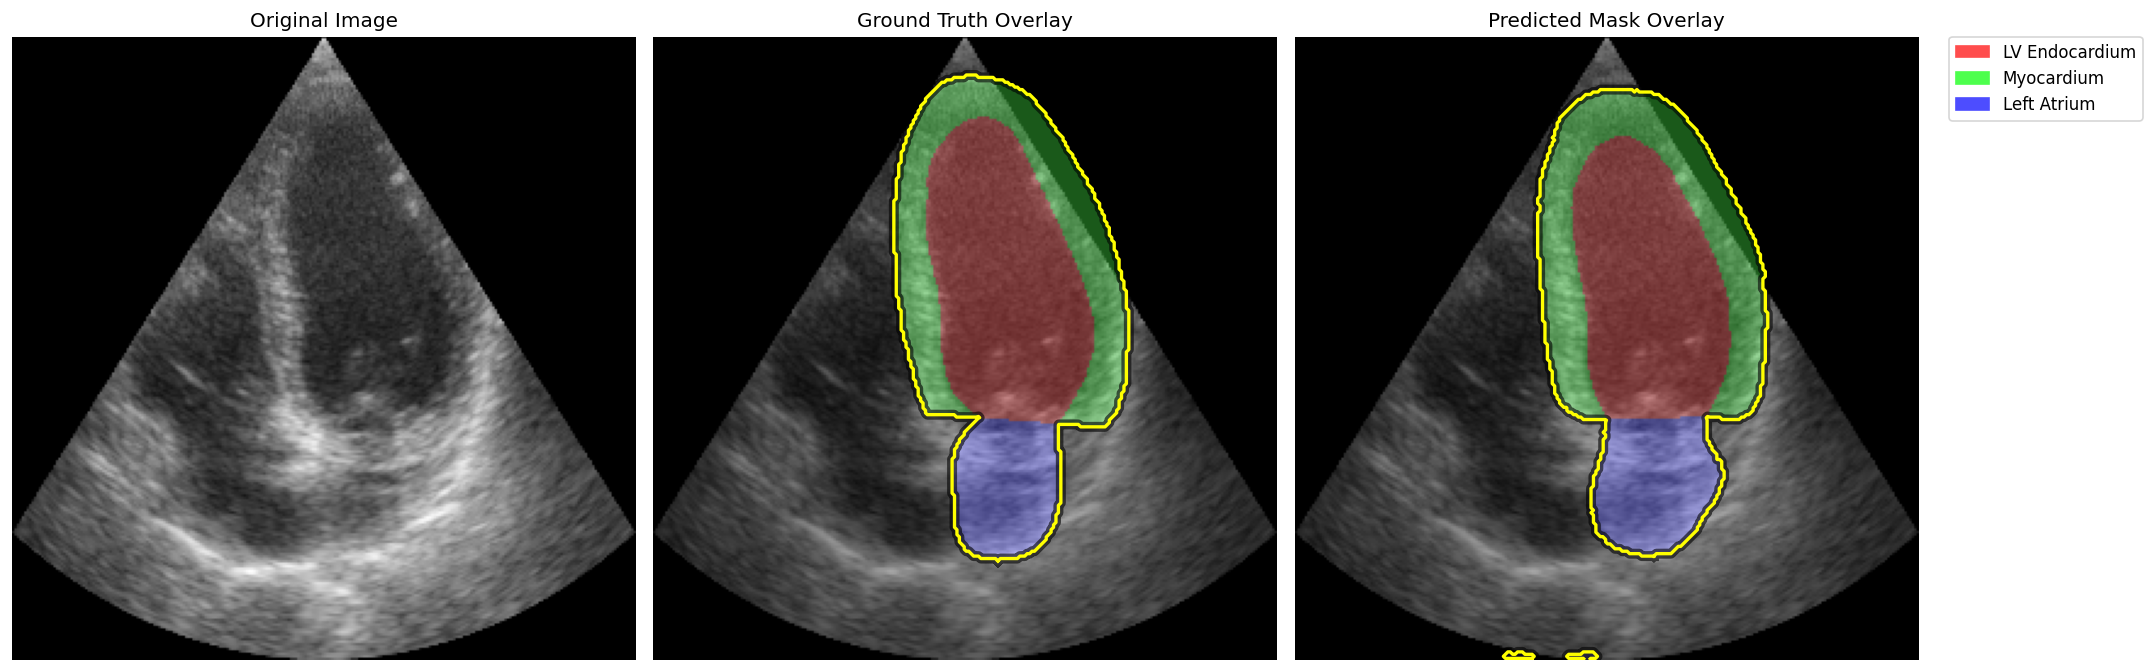

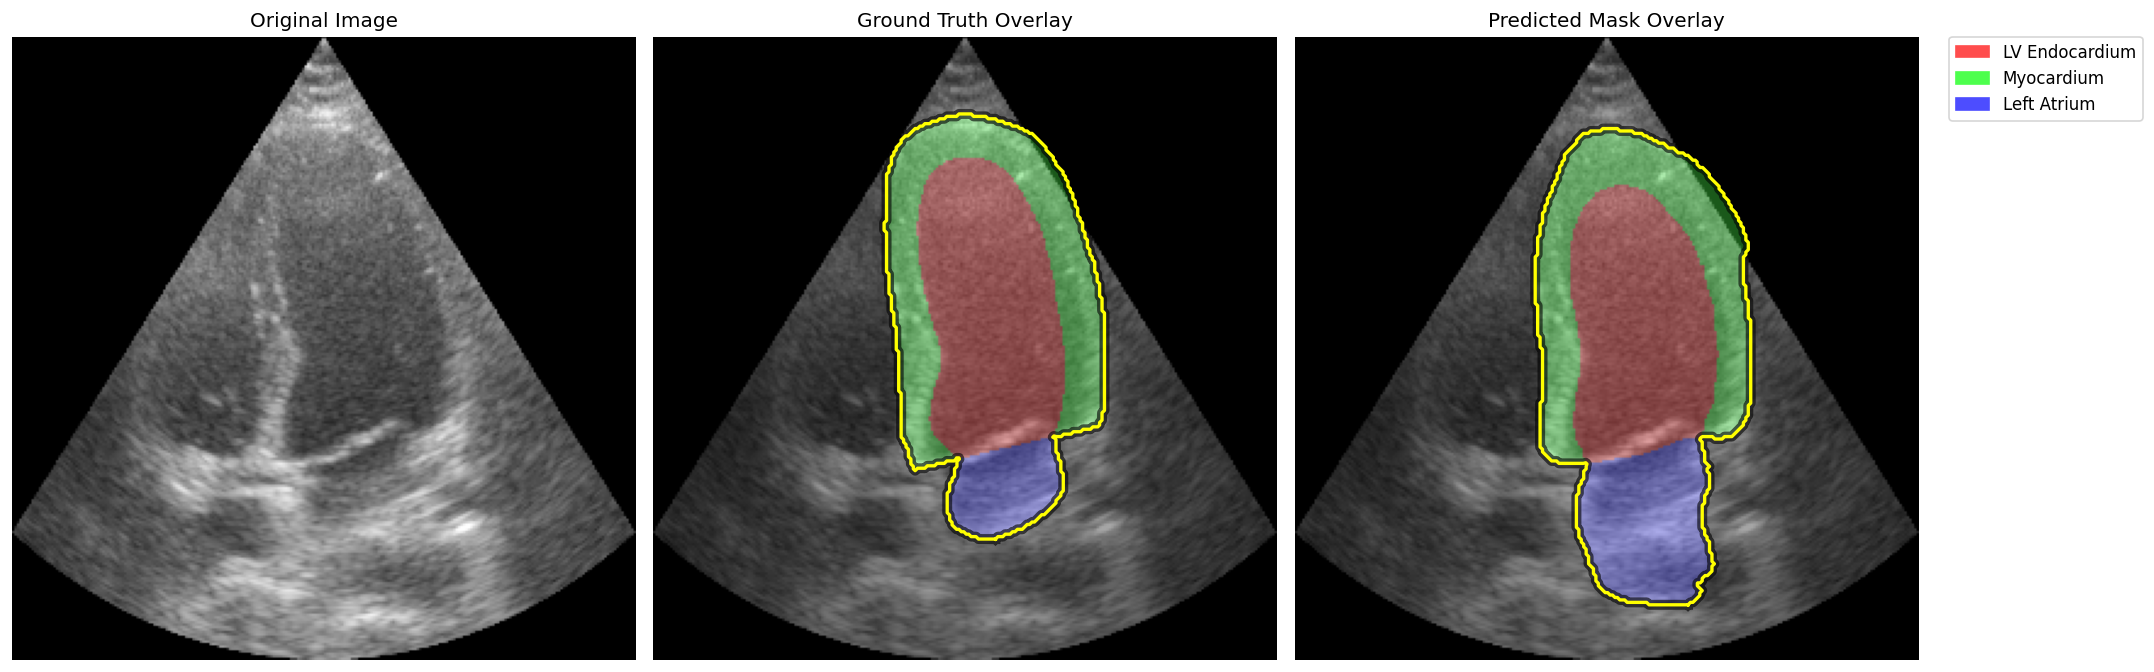

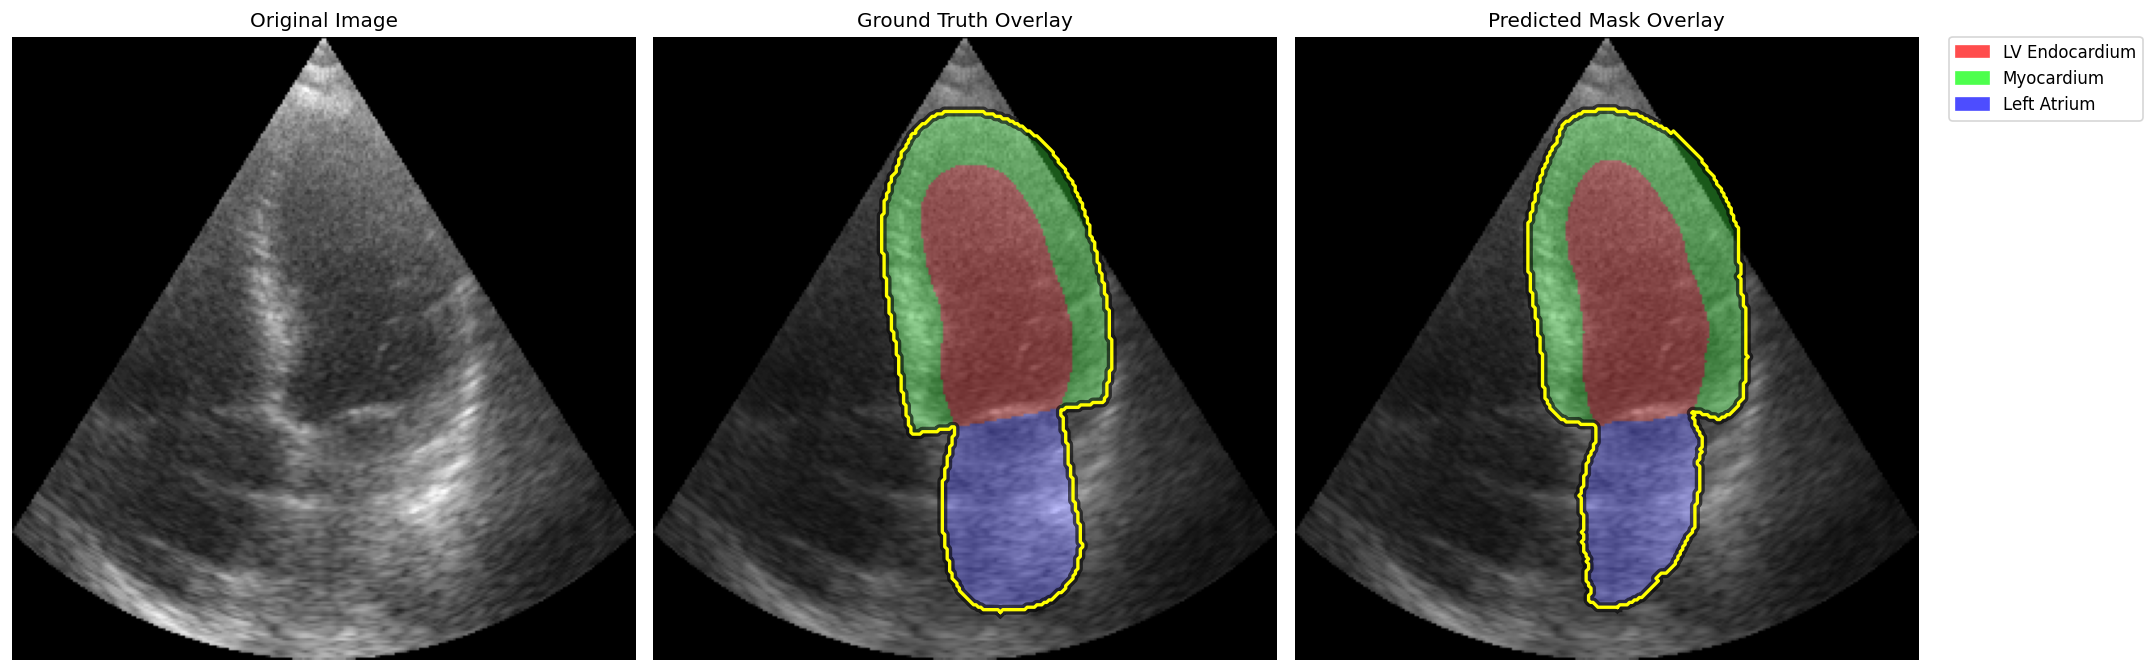

In [121]:
import matplotlib.patches as mpatches

def get_bright_colors():
    # Bright RGB colors for 4 classes (including background black)
    return np.array([
        [0, 0, 0],           # background - black (invisible)
        [1.0, 0.3, 0.3],     # LV Endo - bright red
        [0.3, 1.0, 0.3],     # Myo - bright green
        [0.3, 0.3, 1.0],     # LA - bright blue
    ])

def create_legend():
    colors_arr = get_bright_colors()
    class_names = ['Background', 'LV Endocardium', 'Myocardium', 'Left Atrium']
    patches = []
    for i in range(1, len(class_names)):  # skip background
        rgb = colors_arr[i]
        patch = mpatches.Patch(color=rgb, label=class_names[i])
        patches.append(patch)
    return patches

def visualize_with_legend(model, dataloader, device, num_samples=3, alpha=0.35):
    model.eval()
    samples_shown = 0
    colors_arr = get_bright_colors()
    legend_patches = create_legend()

    with torch.no_grad():
        for imgs, true_masks in dataloader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            imgs = imgs.cpu().numpy()
            true_masks = true_masks.cpu().numpy()

            for i in range(imgs.shape[0]):
                if samples_shown >= num_samples:
                    return

                image = imgs[i][0]
                true_mask = true_masks[i]
                pred_mask = preds[i]

                overlay_true = overlay_mask_transparent(image, true_mask, alpha=alpha, colors_arr=colors_arr)
                overlay_pred = overlay_mask_transparent(image, pred_mask, alpha=alpha, colors_arr=colors_arr)

                fig, axs = plt.subplots(1, 3, figsize=(18, 6), dpi=120)
                axs[0].imshow(image, cmap='gray')
                axs[0].set_title("Original Image")
                axs[1].imshow(overlay_true)
                axs[1].set_title("Ground Truth Overlay")
                axs[2].imshow(overlay_pred)
                axs[2].set_title("Predicted Mask Overlay")

                # Add glow contours for crisp visibility
                plot_contours_glow(axs[1], true_mask, color='yellow', glow_color='black', linewidth=2, glow_width=6)
                plot_contours_glow(axs[2], pred_mask, color='yellow', glow_color='black', linewidth=2, glow_width=6)

                for ax in axs:
                    ax.axis('off')

                # Add legend only once on the prediction plot
                axs[2].legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

                plt.tight_layout()
                plt.show()

                samples_shown += 1

# Run with legend and tweaks:
visualize_with_legend(model, test_loader, device=device, num_samples=3, alpha=0.35)
